# Import of packages and arguments needed for data visualization

In [33]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, MaxNLocator, MultipleLocator,  AutoMinorLocator, FixedLocator
import matplotlib.lines as mlines
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from collections import defaultdict
import numpy as np
import os
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.serif": ["STIXGeneral"],
})

import importlib
import utils
from logger import ExperimentLogger

importlib.reload(utils)
argFile = 'parameters.json'
try:
    del args
except NameError:
    pass
args = utils.loadJson(argFile)    
    
def get_path_to_sim(dataset):
    if dataset == "synthetic":
        path_to_sim = os.path.join(args.path_to_res_folder, f"run_K={args.K}_M={args.M}.npy")
    elif dataset == "MNIST":
        path_to_sim = os.path.join(args.path_to_res_folder, f"run_MNIST.npy")
    elif dataset == "CIFAR":
        path_to_sim = os.path.join(args.path_to_res_folder, f"run_CIFAR.npy")
    elif dataset == "fMNIST":
        path_to_sim = os.path.join(args.path_to_res_folder, f"run_fMNIST.npy")
    return path_to_sim

path_to_sim = os.path.join(args.path_to_res_folder, f"run_K={args.K}_M={args.M}.npy")
path_to_sim_ODEs = os.path.join(args.path_to_res_folder, f"ODES_K={args.K}_M={args.M}.npy")

configs = {
    "standard":  {"colors" : ["#FA7070", "#F8BFD4FF"], "marker" : "*", "marker_size" : 8},
    "Sco-standard":  {"colors" :["#FAC20C", "#EBD17E"], "marker" : "s", "marker_size" : 6},
    "LoRA":         {"colors" : ["#1D4ED8", "#93C5FD"], "marker" : "D", "marker_size" : 6},
    #"only_LoRA":    {"colors" : ["#D81DCF", "#CE73C9"], "marker" : "o", "marker_size" : 8},
    "Sco-LoRA":     {"colors" :["#15803D", "#86EFAC"], "marker" : "o", "marker_size" : 6},
    "global" :{    "legend_label_size" : 14,
                   "labelspacing": 0.25,
                   "axis_label_size": 25,
                   "tick_label_size" : 20,
                   "alpha_sim" : 1,
                   "alpha_ODEs" : 0.7,
                   "markevery_sim" : 15}
}
METHOD_LABELS = {
    "standard": "standard",
    "LoRA": "LoRA",
    "Sco-LoRA": "LoRA + SDGM",
    "Sco-standard": "standard + SDGM",
    "only_LoRA": "only LoRA"
}
BASE_METHOD_LABELS = {
    "Sco-LoRA": "LoRA",
    "Sco_LoRA": "LoRA",
    "Sco-standard": "standard",
    "Sco_standard": "standard",
}

SCORING_CONFIGS = {
    "SDGM": {
        "label": "SDGM",
        "color": "#15803D",        # Dark green (Task 1)
        "light_color": "#86EFAC",  # Light green (Task 2)
        "marker": "o",
        "linestyle": "-",
        "lw": 1,
        "marker_offset": 0
    },
    "inv_SDGM": {
        "label": "inv SDGM",       # Clean label format
        "color": "#FA7070",        # Dark red (Task 1)
        "light_color": "#F8BFD4FF",# Light red/pink (Task 2)
        "marker": "d",
        "linestyle": "-",
        "lw": 1,
        "marker_offset": 0
    },
    "re-use": {
        "label": "Re-use",
        "color": "#FAC20C",        # Dark yellow/gold (Task 1)
        "light_color": "#EBD17E",  # Light yellow/gold (Task 2)
        "marker": "^",
        "linestyle": "-",
        "lw": 1,
        "marker_offset": 5
    }
}

# Some checks to read the saved files

In [34]:
def check_keys_inside_file(runs=False):
    # 2. Extract and display unique parameters
    if not runs:
        print("No runs found in this file or file doesn't exist.")
    else:
        print(f"Total number of logged runs: {len(runs)}\n")
        print("--- UNIQUE PARAMETERS INSIDE THE FILE ---")

        # Grab all metadata keys present in the first run to build our search list
        metadata_keys = runs[0]["metadata"].keys()

        for key in metadata_keys:
            # Use a set comprehension to gather every unique value seen across runs
            unique_values = {run["metadata"].get(key) for run in runs if key in run["metadata"]}

            # Sort if possible for clean reading (falls back to unsorted if types mismatch)
            try:
                sorted_values = sorted(list(unique_values))
            except TypeError:
                sorted_values = list(unique_values)

            print(f"  * {key:<12} : {sorted_values}")
            
def check_match_in_keys(runs=False):
    if not runs:
        print("The file is completely empty or doesn't exist.")
    else:
        meta = runs[0]["metadata"]
        print("--- LIVE PARAMETER DEBUGGER ---")
        print(f"{'Parameter':<12} | {'Inside File (meta)':<20} | {'Current Script (args)':<20} | Match?")
        print("-" * 65)

        # Helper to check type-agnostic matches
        def check(v1, v2, is_float=False):
            if is_float:
                return np.isclose(float(v1), float(v2))
            if str(v1).lower() in ['true', 'false'] or str(v2).lower() in ['true', 'false']:
                b1 = str(v1).lower() in ['true', '1']
                b2 = str(v2).lower() in ['true', '1']
                return b1 == b2
            return str(v1) == str(v2)

        # Test every single constraint from your match function
        print(f"{'L':<12} | {str(meta.get('L')):<20} | {str(getattr(args, 'L', 'MISSING')):<20} | {check(meta.get('L'), getattr(args, 'L', None))}")
        print(f"{'gamma':<12} | {str(meta.get('gamma')):<20} | {str(getattr(args, 'gamma', 'MISSING')):<20} | {check(meta.get('gamma'), getattr(args, 'gamma', None), True)}")
        print(f"{'method':<12} | {str(meta.get('method')):<20} | {str(getattr(args, 'method', 'MISSING')):<20} | {check(meta.get('method'), getattr(args, 'method', None))}")
        print(f"{'rho':<12} | {str(meta.get('rho')):<20} | {str(getattr(args, 'rho', 'MISSING')):<20} | {check(meta.get('rho'), getattr(args, 'rho', None), True)}")
        print(f"{'M':<12} | {str(meta.get('M')):<20} | {str(getattr(args, 'M', 'MISSING')):<20} | {check(meta.get('M'), getattr(args, 'M', None))}")
        print(f"{'K':<12} | {str(meta.get('K')):<20} | {str(getattr(args, 'K', 'MISSING')):<20} | {check(meta.get('K'), getattr(args, 'K', None))}")
        print(f"{'N':<12} | {str(meta.get('N')):<20} | {str(getattr(args, 'N', 'MISSING')):<20} | {check(meta.get('N'), getattr(args, 'N', None))}")
        print(f"{'alpha':<12} | {str(meta.get('alpha')):<20} | {str(getattr(args, 'alpha', 'MISSING')):<20} | {check(meta.get('alpha'), getattr(args, 'alpha', None), True)}")
          
path_to_sim = get_path_to_sim(args.dataset)
runs = ExperimentLogger.load_group(path_to_sim)
runs_ODEs = ExperimentLogger.load_group(path_to_sim_ODEs)

print("checking for sims :")  
check_keys_inside_file(runs)
print("checking for ODEs")
check_keys_inside_file(runs_ODEs)

print("checking for sims :")  
check_match_in_keys(runs)
print("checking for ODEs")
check_match_in_keys(runs_ODEs)

checking for sims :
Total number of logged runs: 2

--- UNIQUE PARAMETERS INSIDE THE FILE ---
  * N            : [1000]
  * M            : [5]
  * K            : [10]
  * rho          : [0.5]
  * dataset      : ['synthetic']
  * method       : ['LoRA', 'standard']
  * scoring_method : ['SDGM']
  * rows_to_freeze : [5]
  * informed_initialization : [False]
  * alpha        : [50]
  * gamma        : [1]
  * L            : [5]
  * alpha_W      : [0.5]
  * alpha_H      : [0.5]
  * alpha_a      : [0.5]
  * alpha_b      : [0.5]
  * teacher_initialization : ['committee']
  * teacher_hl_initialization : ['ungraded']
  * teacher_activation_function : ['erf']
  * student_activation_function : ['erf']
  * student_initialization : ['unspecializing']
  * seed         : [1001]
checking for ODEs
Total number of logged runs: 2

--- UNIQUE PARAMETERS INSIDE THE FILE ---
  * N            : [1000]
  * M            : [5]
  * K            : [10]
  * rho          : [0.5]
  * dataset      : ['synthetic']
  *

# Import the data from past runs with constraints

In [35]:
def metadata_matches(meta, args, synthetic=True, rho=None, method=None, scoring_method=None):
    rho = args.rho if rho is None else rho
    method = args.method if method is None else method
    scoring_method = getattr(args, "scoring_method", None) if scoring_method is None else scoring_method

    checks = {
        "method": (meta.get("method"), method),
        "rho": (float(meta.get("rho", 0.0)), float(rho)),
        "K": (int(meta.get("K", 0)), int(args.K)),
        "M": (int(meta.get("M", 0)), int(args.M)),
        #"gamma": (float(meta["gamma"]), float(args.gamma)),
        #"activation_function": (
        #    str(meta["activation_function"]),
        #    str(args.activation_function),
        #),
        #"informed_initialization": (
        #    str(meta["informed_initialization"]),
        #    str(args.informed_initialization)
        #),
    }
    if synthetic:
        checks["alpha"] = (float(meta.get("alpha", 0.0)), float(args.alpha))
        checks["N"] = (int(meta.get("N", 0)), int(args.N))
    # Conditionally check scoring method if the method utilizes scoring mechanisms
    if method in ["Sco-LoRA", "Sco-standard"] and scoring_method is not None:
        checks["scoring_method"] = (str(meta.get("scoring_method", "")), str(scoring_method))

    if method not in ["Sco-standard", "standard"]:
        checks["L"] = (int(meta.get("L", 0)), int(args.L))

    ok = True

    for key, (found, expected) in checks.items():
        if key == "rho":
            match = np.isclose(found, expected)
        else:
            match = found == expected

        if not match:
            # print(f"Mismatch for '{key}': found {found}, expected {expected}")
            ok = False
            
    return ok

def load_runs_with_constraints(path, args, rho=None):
    runs = ExperimentLogger.load_group(path)

    filtered = [
        r for r in runs
        if metadata_matches(r["metadata"], args,rho)
    ]

    if len(filtered) == 0:
        print(f"No matching configurations found in {os.path.basename(path)}!")
        return None

    if len(filtered) > 1:
        print(f"{len(filtered)} runs found in {os.path.basename(path)}!")
        for i in range(len(filtered)):
            print(filtered[i]["metadata"])
        return [filtered[0]]
    
    return filtered

def select_run_by_scoring(runs, args, method, scoring_method):
    """Filters trajectory runs matching both method and scoring_method."""
    original_scoring = getattr(args, "scoring_method", None)
    args.scoring_method = scoring_method
    try:
        for r in runs:
            meta = r.get("metadata", {})
            if metadata_matches(meta, args, method=method):
                return r
    finally:
        args.scoring_method = original_scoring
    return None

def runs_to_dict(path,args,rho=None):
    """Load runs with constraints and convert them into a dictionary format suitable for analysis.
    Input:
        path (str): The path to the file containing the runs.
        args (Namespace): The arguments containing the constraints.
        rho (float, optional): The value of rho to match.
    Output:
        dict: A dictionary containing the metadata and logs of the runs, organized by keys.
    """
    runs = load_runs_with_constraints(path, args, rho)
    #print("runs", runs)
    if runs == None :
        return None
    logs = runs[0]["logs"]

    out = {"metadata": runs[0]["metadata"]}

    # global steps if consistent, otherwise keep per-key
    out["steps"] = {}

    for key, entry in logs.items():
        out["steps"][key] = np.array(entry["steps"])

        values = entry["values"]

        if len(values) == 0:
            continue

        out[key] = np.array(values, dtype=object)

    return out
   
class FixedExponentFormatter(ScalarFormatter):
    """ScalarFormatter that forces a fixed exponent (e.g., 10^5)."""
    def __init__(self, exponent=5, useMathText=True):
        super().__init__(useMathText=useMathText)
        self.exponent = exponent

    def _set_order_of_magnitude(self):
        self.orderOfMagnitude = self.exponent
        
# Load the simulation
path_to_sim = get_path_to_sim(args.dataset)
path_to_sim_ODEs = os.path.join(args.path_to_res_folder, f"ODES_K={args.K}_M={args.M}.npy")
print(path_to_sim)
df = runs_to_dict(path_to_sim, args)
df_ODES = runs_to_dict(path_to_sim_ODEs, args)
#
#print(df["metadata"])
#print(df_ODES["metadata"])

/home/theom/continual_learning/results/run_K=10_M=5.npy


# 1. Compare LGS with LoRA setting, show the slowing down of dynamic and slightly smaller forgetting.

In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import FixedLocator, AutoMinorLocator

def compare_runs(args, label_run1, label_run2, all_sim_runs, all_ode_runs):
    """
    Compare two run methods side-by-side with dynamic, clean legend formatting
    and unified marker sizes scaled for ICLR publication standards.
    """
    # 1. Publication Typography & Line Scaling
    FONT_LABEL = 8.0
    FONT_TICK = 6.5
    
    lw_ODEs = 1.0
    lw_task_switch = 0.8
    markeredge_w = 0.8

    alpha_sim = configs["global"]["alpha_sim"]
    alpha_ODEs = configs["global"]["alpha_ODEs"]
    markevery_sim = configs["global"]["markevery_sim"]

    P_time = args.N * args.alpha
    P_total = 2 * P_time

    # Helper function to guarantee matching marker sizes for SIMS and LEGEND
    def get_marker_size(method_key):
        resolved_name = METHOD_LABELS.get(method_key, method_key)
        return 4.12 if resolved_name == "standard" else 3.6
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(5.5, 2.2), sharex=True, layout='constrained')

    x_formatter = FixedExponentFormatter(exponent=5, useMathText=True)

    for ax in (ax1, ax2):
        ax.set_xlabel(r"$t$", fontsize=FONT_LABEL, labelpad=1)
        ax.xaxis.set_major_locator(FixedLocator(np.linspace(0, P_total, 6)))
        ax.xaxis.set_major_formatter(x_formatter)

        ax.tick_params(axis='both', which='both', length=0)
        ax.tick_params(axis='x', which='both', bottom=True, direction='out', length=2.5, width=0.6, labelsize=FONT_TICK)
        ax.tick_params(axis='y', which='both', left=True, direction='out', length=2.5, width=0.6, labelsize=FONT_TICK)
        ax.xaxis.get_offset_text().set_fontsize(FONT_TICK)

    def _is_scoring_method(method):
        return str(method).strip() in ["Sco-LoRA", "Sco_LoRA", "Sco-standard", "Sco_standard"]

    def _find_single_run(runs, method):
        if not runs:
            return None
        for r in runs:
            meta = r.get("metadata", {})
            if metadata_matches(meta, args, method=method):
                return r
        return None

    plotted_scoring_methods = set()

    def _plot_panel(ax, label_run):
        if _is_scoring_method(label_run):
            for scoring_name, cfg in SCORING_CONFIGS.items():
                sim_run = select_run_by_scoring(all_sim_runs, args, label_run, scoring_name)
                ode_run = select_run_by_scoring(all_ode_runs, args, label_run, scoring_name)
                offset = cfg.get("marker_offset", 0)

                has_plotted_data = False
                color_primary = cfg["color"]
                color_light = cfg.get("light_color", color_primary)
                run_markersize = get_marker_size(scoring_name)

                # ODEs
                if ode_run is not None:
                    ode_logs = ode_run.get("logs", ode_run)
                    if "test_loss_1" in ode_logs and "test_loss_2" in ode_logs:
                        v1 = ode_logs["test_loss_1"]["values"] if isinstance(ode_logs["test_loss_1"], dict) else ode_logs["test_loss_1"]
                        v2 = ode_logs["test_loss_2"]["values"] if isinstance(ode_logs["test_loss_2"], dict) else ode_logs["test_loss_2"]
                        loss1, loss2 = np.asarray(v1, dtype=np.float64), np.asarray(v2, dtype=np.float64)
                        t_span = np.arange(len(loss1)) * args.integration_step * args.N

                        ax.plot(t_span, np.log10(loss2), color=color_light, linestyle="-",
                                lw=cfg.get("lw", lw_ODEs), alpha=alpha_ODEs, zorder=2)
                        ax.plot(t_span, np.log10(loss1), color=color_primary, linestyle=cfg.get("linestyle", "-"),
                                lw=cfg.get("lw", lw_ODEs), alpha=alpha_ODEs, zorder=3)
                        has_plotted_data = True

                # Simulation
                if sim_run is not None:
                    sim_logs = sim_run.get("logs", sim_run)
                    if "test_loss_1" in sim_logs and "test_loss_2" in sim_logs:
                        if isinstance(sim_logs["test_loss_1"], dict):
                            steps = np.array(sim_logs["test_loss_1"]["steps"])
                            v1, v2 = sim_logs["test_loss_1"]["values"], sim_logs["test_loss_2"]["values"]
                        else:
                            steps = np.array(sim_run["steps"]["test_loss_1"])
                            v1, v2 = sim_logs["test_loss_1"], sim_logs["test_loss_2"]

                        ax.plot(steps, np.log10(np.asarray(v2, dtype=np.float64)),
                                linestyle='None', marker=cfg["marker"], markevery=(offset, markevery_sim),
                                color=color_light, markerfacecolor='white', markeredgewidth=markeredge_w,
                                markersize=run_markersize, alpha=alpha_sim, zorder=3)
                        ax.plot(steps, np.log10(np.asarray(v1, dtype=np.float64)),
                                linestyle='None', marker=cfg["marker"], markevery=(offset, markevery_sim),
                                color=color_primary, markerfacecolor="white", markeredgewidth=markeredge_w,
                                markersize=run_markersize, alpha=alpha_sim, zorder=4)
                        has_plotted_data = True

                if has_plotted_data:
                    plotted_scoring_methods.add((label_run, scoring_name))

        else:
            sim_run = _find_single_run(all_sim_runs, label_run)
            ode_run = _find_single_run(all_ode_runs, label_run)

            run_colors = configs[label_run]["colors"]
            run_marker = configs[label_run]["marker"]
            run_markersize = get_marker_size(label_run)

            if ode_run is not None:
                ode_logs = ode_run.get("logs", ode_run)
                v1 = ode_logs["test_loss_1"]["values"] if isinstance(ode_logs["test_loss_1"], dict) else ode_logs["test_loss_1"]
                v2 = ode_logs["test_loss_2"]["values"] if isinstance(ode_logs["test_loss_2"], dict) else ode_logs["test_loss_2"]
                loss1, loss2 = np.asarray(v1, dtype=np.float64), np.asarray(v2, dtype=np.float64)
                t_span = np.arange(len(loss1)) * args.integration_step * args.N

                ax.plot(t_span, np.log10(loss2), color=run_colors[1], alpha=alpha_ODEs, lw=lw_ODEs, zorder=2)
                ax.plot(t_span, np.log10(loss1), color=run_colors[0], alpha=alpha_ODEs, lw=lw_ODEs, zorder=3)

            if sim_run is not None:
                sim_logs = sim_run.get("logs", sim_run)
                if isinstance(sim_logs["test_loss_1"], dict):
                    steps = np.array(sim_logs["test_loss_1"]["steps"])
                    v1, v2 = sim_logs["test_loss_1"]["values"], sim_logs["test_loss_2"]["values"]
                else:
                    steps = np.array(sim_run["steps"]["test_loss_1"])
                    v1, v2 = sim_logs["test_loss_1"], sim_logs["test_loss_2"]

                ax.plot(steps, np.log10(np.asarray(v2, dtype=np.float64)),
                        linestyle='None', marker=run_marker, markersize=run_markersize, markevery=markevery_sim,
                        color=run_colors[1], markerfacecolor="white", markeredgewidth=markeredge_w, alpha=alpha_sim, lw=1, zorder=3)
                ax.plot(steps, np.log10(np.asarray(v1, dtype=np.float64)),
                        linestyle='None', marker=run_marker, markersize=run_markersize, markevery=markevery_sim,
                        color=run_colors[0], markerfacecolor="white", markeredgewidth=markeredge_w, alpha=alpha_sim, zorder=4)

    _plot_panel(ax1, label_run1)
    _plot_panel(ax2, label_run2)

    ax1.axvline(x=P_time, color="grey", lw=lw_task_switch, zorder=1)
    ax2.axvline(x=P_time, color="grey", lw=lw_task_switch, zorder=1)

    fig.canvas.draw()

    ymin1, ymax1 = ax1.get_ylim()
    ymin2, ymax2 = ax2.get_ylim()
    unified_ylim = (min(ymin1, ymin2), max(ymax1, ymax2))

    for ax in [ax1, ax2]:
        ax.set_ylim(unified_ylim)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(0.6)
        ax.spines['bottom'].set_linewidth(0.6)

        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='both', which='minor', length=0)

        # Subtle publication-style gridlines
        ax.grid(True, which='major', axis='both', linestyle='-', color="#C5BFBF", linewidth=0.4, alpha=0.7, zorder=0)
        ax.grid(True, which='minor', axis='both', linestyle=':', color="#E0E0E0", linewidth=0.3, alpha=0.5, zorder=0)

    ax1.set_ylabel(r"$\log \epsilon^*$", fontsize=FONT_LABEL, labelpad=2)
    ax2.tick_params(axis='y', which='both', labelleft=False)

    # Dynamic Legend Formatting (Uses identical get_marker_size logic)
    legend_handles = []
    seen_labels = set()

    for label_run in [label_run1, label_run2]:
        if _is_scoring_method(label_run):
            base_name = BASE_METHOD_LABELS.get(label_run, label_run)
            for scoring_name, cfg in SCORING_CONFIGS.items():
                if (label_run, scoring_name) in plotted_scoring_methods:
                    lbl = f"{base_name} + {cfg['label']}"
                    m_size = get_marker_size(scoring_name)
                    if lbl not in seen_labels:
                        legend_handles.append(
                            mlines.Line2D([], [], color=cfg["color"], marker=cfg["marker"], linestyle='None',
                                          markersize=m_size, markerfacecolor="white", markeredgewidth=markeredge_w, label=lbl)
                        )
                        seen_labels.add(lbl)
        else:
            lbl = METHOD_LABELS.get(label_run, label_run)
            m_size = get_marker_size(label_run)
            if lbl not in seen_labels:
                legend_handles.append(
                    mlines.Line2D([], [], color=configs[label_run]["colors"][0], marker=configs[label_run]["marker"], linestyle='None',
                                  markersize=m_size, markerfacecolor="white", markeredgewidth=markeredge_w, label=lbl)
                )
                seen_labels.add(lbl)

    if legend_handles:
        leg = fig.legend(
            handles=legend_handles,
            loc='lower center',
            bbox_to_anchor=(0.5, -0.1),
            bbox_transform=fig.transFigure,
            ncol=min(len(legend_handles), 4),
            frameon=True,
            edgecolor='#e2e8f0',
            facecolor='white',
            fontsize=FONT_TICK,
            borderpad=0.3,
            handletextpad=0.4,
            columnspacing=1.0
        )
        for text in leg.get_texts():
            text.set_fontweight('bold')

    os.makedirs("for_paper", exist_ok=True)
    plt.savefig(
        f"for_paper/th_sim_N_{args.N}_K_{args.K}_M_{args.M}_rho_{args.rho}_rank_{args.L}_gamma_{args.gamma}.pdf",
        bbox_inches='tight',
        pad_inches=0.02,
    )
    plt.show()

/tmp/ipykernel_3820598/2297766125.py:117: MatplotlibDeprecationWarning: The orderOfMagnitude attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.orderOfMagnitude = self.exponent


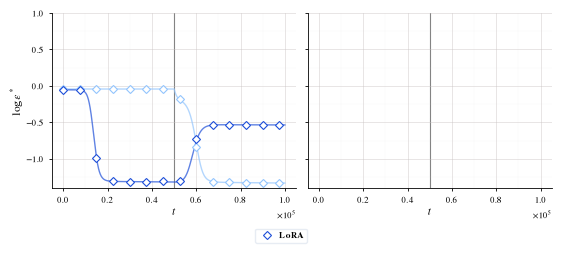

In [37]:
label_run1="LoRA"
label_run2="Sco-LoRA"
args.rho=0.5

all_sim_runs = ExperimentLogger.load_group(path_to_sim)
all_ode_runs = ExperimentLogger.load_group(path_to_sim_ODEs)

compare_runs(
    args=args,
    label_run1=label_run1,
    label_run2=label_run2,
    all_sim_runs=all_sim_runs,
    all_ode_runs=all_ode_runs
)

# 1bis. Comparing scoring procedures

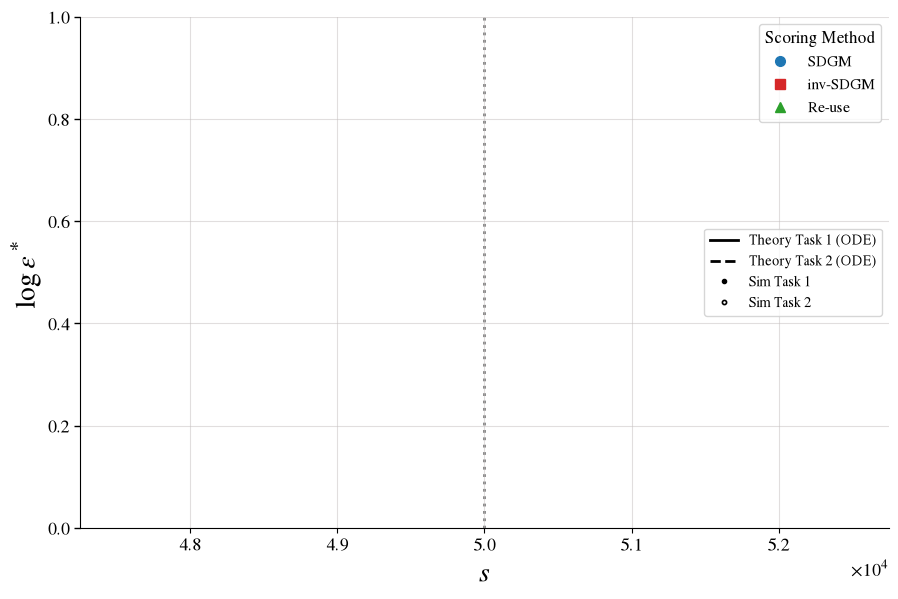

In [38]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter, FormatStrFormatter
import matplotlib.lines as mlines

# --- Configuration for Scoring Mechanisms (with offsets & styles to prevent total overlap) ---
SCORING_CONFIGS = {
    "SDGM": {
        "label": "SDGM",
        "color": "#1f77b4",  # Blue
        "marker": "o",
        "linestyle": "-",
        "lw": 3.0,
        "marker_offset": 0   # Base marker position
    },
    "inv_SDGM": {
        "label": "inv-SDGM",
        "color": "#d62728",  # Red
        "marker": "s",
        "linestyle": "--",
        "lw": 2.0,
        "marker_offset": 0
    },
    "re-use": {
        "label": "Re-use",
        "color": "#2ca02c",  # Green
        "marker": "^",
        "linestyle": "-.",   # Dash-dot to separate overlapping lines
        "lw": 1.5,
        "marker_offset": 10  # Shifted marker position so they alternate
    }
}

def select_run_by_scoring(runs, args, method, scoring_method):
    """Filters trajectory runs matching both method and scoring_method."""
    original_scoring = getattr(args, "scoring_method", None)
    args.scoring_method = scoring_method  # Temporarily sync for metadata_matches
    try:
        for r in runs:
            meta = r.get("metadata", {})
            if metadata_matches(meta, args, method=method):
                return r
    finally:
        args.scoring_method = original_scoring  # Restore original
    return None

def plot_scoring_mechanisms_with_theory(fig, ax, all_sim_runs, all_ode_runs, target_method="Sco-standard"):
    markevery_sim = 2
    markersize_sim = 6.5

    for scoring_name, cfg in SCORING_CONFIGS.items():
        sim_run = select_run_by_scoring(all_sim_runs, args, target_method, scoring_name)
        ode_run = select_run_by_scoring(all_ode_runs, args, target_method, scoring_name)
        offset = cfg.get("marker_offset", 0)

        # --- THEORY (ODE Trajectories) ---
        if ode_run is not None:
            ode_logs = ode_run["logs"]
            if "test_loss_1" in ode_logs and "test_loss_2" in ode_logs:
                loss_ref_1 = np.asarray(ode_logs["test_loss_1"]["values"], dtype=np.float64)
                loss_ref_2 = np.asarray(ode_logs["test_loss_2"]["values"], dtype=np.float64)
                t_span = np.arange(len(loss_ref_1)) * args.integration_step * args.N

                # Task 1 Theory & Task 2 Theory with distinct styles/widths
                ax.plot(t_span, np.log10(loss_ref_1), color=cfg["color"], 
                        linestyle=cfg["linestyle"], lw=cfg["lw"], alpha=0.85, zorder=3)
                ax.plot(t_span, np.log10(loss_ref_2), color=cfg["color"], 
                        linestyle='--', lw=cfg["lw"], alpha=0.85, zorder=2)

        # --- SIMULATION (Empirical Data Points with Staggered Markers) ---
        if sim_run is not None and "logs" in sim_run:
            sim_logs = sim_run["logs"]
            if "test_loss_1" in sim_logs and "test_loss_2" in sim_logs:
                steps = np.array(sim_logs["test_loss_1"]["steps"])

                # Task 1 Simulation: Staggered via markevery=(offset, interval)
                ax.plot(steps, np.log10(np.asarray(sim_logs["test_loss_1"]["values"], dtype=np.float64)),
                        linestyle='None', marker=cfg["marker"], markevery=(offset, markevery_sim),
                        color=cfg["color"], markerfacecolor=cfg["color"], markersize=markersize_sim, 
                        alpha=0.9, zorder=4)

                # Task 2 Simulation: Staggered open markers
                ax.plot(steps, np.log10(np.asarray(sim_logs["test_loss_2"]["values"], dtype=np.float64)),
                        linestyle='None', marker=cfg["marker"], markevery=(offset, markevery_sim),
                        color=cfg["color"], markerfacecolor='white', markeredgewidth=1.2, 
                        markersize=markersize_sim, alpha=0.9, zorder=4)

    # Vertical line for Task Switch
    P_time = args.N * args.alpha if args.dataset == "synthetic" else 200000
    ax.axvline(x=P_time, color="grey", linestyle=":", lw=2, zorder=1)

    # Formatting
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlabel(r"$s$", fontsize=20)
    ax.set_ylabel(r"$\log \epsilon^*$", fontsize=20)
    ax.tick_params(axis='both', which='both', labelsize=13)
    ax.tick_params(axis='y', which='both', left=True, direction='out', length=4, width=1.0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.get_offset_text().set_fontsize(13)

# --- Load Data & Plot ---
path_to_sim = get_path_to_sim(args.dataset)
path_to_sim_ODEs = os.path.join(args.path_to_res_folder, f"ODES_K={args.K}_M={args.M}.npy")

all_sim_runs = ExperimentLogger.load_group(path_to_sim)
all_ode_runs = ExperimentLogger.load_group(path_to_sim_ODEs)

fig, ax = plt.subplots(figsize=(9, 6))
plot_scoring_mechanisms_with_theory(fig, ax, all_sim_runs, all_ode_runs, target_method="Sco-LoRA")

ax.grid(True, which='major', axis='both', linestyle='-', color="#C5BFBF", linewidth=0.8, alpha=0.5, zorder=0)

# --- Custom Legend: Mechanics vs Theory/Simulation ---
legend_mechanisms = [
    mlines.Line2D([], [], color=cfg["color"], marker=cfg["marker"], linestyle='None', 
                  markersize=7, label=cfg["label"])
    for cfg in SCORING_CONFIGS.values()
]

legend_styles = [
    mlines.Line2D([], [], color='black', linestyle='-', lw=2, label='Theory Task 1 (ODE)'),
    mlines.Line2D([], [], color='black', linestyle='--', lw=2, label='Theory Task 2 (ODE)'),
    mlines.Line2D([], [], color='black', marker='o', linestyle='None', markerfacecolor='black', label='Sim Task 1'),
    mlines.Line2D([], [], color='black', marker='o', linestyle='None', markerfacecolor='white', markeredgewidth=1.2, label='Sim Task 2'),
]

# Add legends explicitly
leg_mech = ax.legend(handles=legend_mechanisms, loc='upper right', frameon=True, title="Scoring Method", fontsize=11, title_fontsize=12)
ax.add_artist(leg_mech)
ax.legend(handles=legend_styles, loc='center right', frameon=True, fontsize=10)

os.makedirs("for_paper", exist_ok=True)
plt.tight_layout()
plt.savefig("for_paper/scoring_mechanisms_theory_vs_sim.pdf", bbox_inches='tight')
plt.show()

# Fig 2

In [39]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import matplotlib.lines as mlines

def select_all_matching_runs(runs, args, method):
    """
    Finds all runs matching the experiment parameters across all seeds.
    """
    synthetic = True if args.dataset == "synthetic" else False
    matching_runs = []
    for r in runs:
        if metadata_matches(r["metadata"], args, method=method, synthetic=synthetic):
            matching_runs.append(r)
    return matching_runs

def select_single_trajectory_run(runs, args, method):
    synthetic = True if args.dataset == "synthetic" else False
    for r in runs:
        if metadata_matches(r["metadata"], args, method=method, synthetic=synthetic):
            return r
    return None

def plot_all_protocols(all_sim_runs, all_ode_runs, methods_to_plot=None):
    lw_task1 = 3.0
    lw_task2 = 3.0
    markevery_sim = 1
    is_synthetic = (args.dataset == "synthetic")
    
    fig, ax = plt.subplots(figsize=(9, 6))

    if methods_to_plot is None:
        target_configs = {k: v for k, v in configs.items() if k != "global"}
    else:
        target_configs = {k: v for k, v in configs.items() if k in methods_to_plot}

    for label, cfg in target_configs.items():
        if is_synthetic:
            # --- SYNTHETIC DATASET: ODE + Single Trajectory Markers ---
            sim_run = select_single_trajectory_run(all_sim_runs, args, label)
            ode_run = select_single_trajectory_run(all_ode_runs, args, label)
            
            if ode_run is not None:
                ode_logs = ode_run["logs"]
                if "test_loss_1" in ode_logs and "test_loss_2" in ode_logs:
                    loss_ref_1 = np.asarray(ode_logs["test_loss_1"]["values"], dtype=np.float64)
                    loss_ref_2 = np.asarray(ode_logs["test_loss_2"]["values"], dtype=np.float64)
                    t_span = np.arange(len(loss_ref_1)) * args.integration_step * args.N

                    ax.plot(t_span, np.log10(loss_ref_1),
                            color=cfg["colors"][0], linestyle='-', lw=lw_task1, alpha=0.7, zorder=3)
                    ax.plot(t_span, np.log10(loss_ref_2),
                            color=cfg["colors"][1], linestyle='-', lw=lw_task2, alpha=0.7, zorder=1)

            if sim_run is not None and "logs" in sim_run:
                sim_logs = sim_run["logs"]
                if "test_loss_1" in sim_logs and "test_loss_2" in sim_logs:
                    steps = np.array(sim_logs["test_loss_1"]["steps"])

                    ax.plot(steps, np.log10(np.asarray(sim_logs["test_loss_1"]["values"], dtype=np.float64)),
                            linestyle='None', marker=cfg["marker"], markevery=markevery_sim,
                            color=cfg["colors"][0], markerfacecolor='white', markersize=cfg["marker_size"], 
                            markeredgewidth=1.5, alpha=1.0, zorder=4)

                    ax.plot(steps, np.log10(np.asarray(sim_logs["test_loss_2"]["values"], dtype=np.float64)),
                            linestyle='None', marker=cfg["marker"], markevery=markevery_sim,
                            color=cfg["colors"][1], markerfacecolor='white', markersize=cfg["marker_size"], 
                            markeredgewidth=1.5, alpha=1.0, zorder=2)
        else:
            # --- REAL DATASETS: Aggregate across seeds (Mean +- Std Shading) ---
            matching_runs = select_all_matching_runs(all_sim_runs, args, label)
            if not matching_runs:
                continue

            loss1_runs, loss2_runs = [], []
            ref_steps = None

            for r in matching_runs:
                sim_logs = r.get("logs", {})
                if "test_loss_1" in sim_logs and "test_loss_2" in sim_logs:
                    if ref_steps is None:
                        ref_steps = np.array(sim_logs["test_loss_1"]["steps"])
                    
                    l1 = np.log10(np.asarray(sim_logs["test_loss_1"]["values"], dtype=np.float64))
                    l2 = np.log10(np.asarray(sim_logs["test_loss_2"]["values"], dtype=np.float64))
                    
                    loss1_runs.append(l1)
                    loss2_runs.append(l2)

            if loss1_runs and loss2_runs:
                loss1_arr = np.array(loss1_runs)  # Shape: (num_seeds, num_steps)
                loss2_arr = np.array(loss2_runs)  # Shape: (num_seeds, num_steps)

                mean1, std1 = np.mean(loss1_arr, axis=0), np.std(loss1_arr, axis=0)
                mean2, std2 = np.mean(loss2_arr, axis=0), np.std(loss2_arr, axis=0)

                # Plot Task 1 Mean + Fill Standard Deviation
                ax.plot(ref_steps, mean1, color=cfg["colors"][0], linestyle='-', lw=lw_task1, zorder=4)
                ax.fill_between(ref_steps, mean1 - std1, mean1 + std1, color=cfg["colors"][0], alpha=0.25, zorder=3)

                # Plot Task 2 Mean + Fill Standard Deviation
                ax.plot(ref_steps, mean2, color=cfg["colors"][1], linestyle='-', lw=lw_task2, zorder=2)
                ax.fill_between(ref_steps, mean2 - std2, mean2 + std2, color=cfg["colors"][1], alpha=0.25, zorder=1)

    # Set phase transition vertical line
    if args.dataset == "synthetic":
        P_time = args.N * args.alpha   
    elif args.dataset == "MNIST":
        P_time = 30000
    elif args.dataset in ["CIFAR", "fMNIST"]:
        P_time = 12000
    else:
        raise ValueError("NOT IMPLEMENTED") 

    ax.axvline(x=P_time, color="grey", lw=2, zorder=0)
    
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0,0))
    ax.xaxis.set_major_formatter(formatter)
    ax.set_xlabel(r"$t$", fontsize=30)
    ax.set_ylabel(r"$\log \epsilon^*$", fontsize=30)
    ax.tick_params(axis='both', which='both', labelsize=20)
    ax.tick_params(axis='y', which='both', left=True, direction='out', length=4, width=1.0)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.get_offset_text().set_fontsize(20)
    
    ax.grid(True, which='major', axis='both', linestyle='-', color="#C5BFBF", linewidth=0.8, alpha=0.8, zorder=0)

    # Format legend handles according to dataset type
    legend_handles = []
    for m, cfg in target_configs.items():
        if is_synthetic:
            handle = mlines.Line2D([], [], color=cfg["colors"][0], marker=cfg["marker"], linestyle='-',
                                   markersize=cfg["marker_size"], markerfacecolor="white", markeredgewidth=1.5, 
                                   label=METHOD_LABELS.get(m, m))
        else:
            handle = mlines.Line2D([], [], color=cfg["colors"][0], linestyle='-', lw=2.5,
                                   label=METHOD_LABELS.get(m, m))
        legend_handles.append(handle)

    leg = ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.22), 
                    ncol=len(methods_to_plot), frameon=True, edgecolor='#e2e8f0', facecolor='white', fontsize=14)
    for text in leg.get_texts():
        text.set_fontweight('bold')

    plt.tight_layout()
    plt.savefig("for_paper/all_losses.pdf", bbox_inches='tight')
    plt.show()

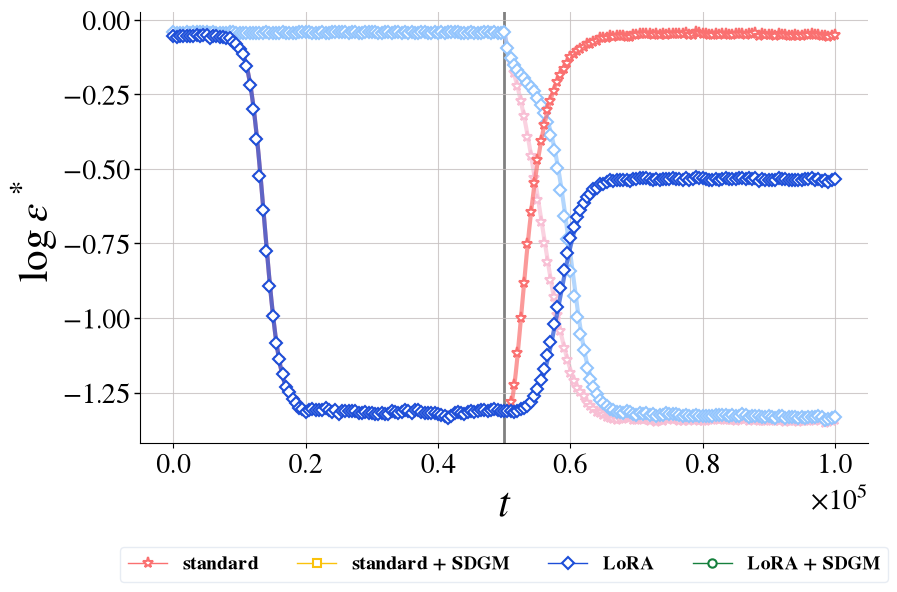

In [40]:
path_to_sim = get_path_to_sim(args.dataset)
path_to_sim_ODEs = os.path.join(args.path_to_res_folder, f"ODES_K={args.K}_M={args.M}.npy")
#all_sim_runs = ExperimentLogger.load_group(path_to_sim)
all_ode_runs = ExperimentLogger.load_group(path_to_sim_ODEs)
methods_to_plot=["standard", "LoRA", "Sco-LoRA", "Sco-standard"]
plot_all_protocols(all_sim_runs, all_ode_runs, methods_to_plot=methods_to_plot)

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.ticker import ScalarFormatter

# Assuming ExperimentLogger and your selection helpers are imported here
# from your_module import ExperimentLogger, select_single_trajectory_run, select_all_matching_runs, configs, METHOD_LABELS

def plot_theory_vs_real_dataset(
    args,
    dataset_name,
    methods_to_plot,
    save_path=None,
):
    """
    ICLR-style 1x2 figure.

    Left:
        Theoretical ODE prediction + Experimental synthetic SGD results.

    Right:
        Experimental SGD results on the real dataset
        (e.g. MNIST, CIFAR, fMNIST), averaged over seeds.
    """
    
    # Set dynamic default save path if none is provided
    if save_path is None:
        save_path = f"for_paper/theory_vs_{dataset_name}.pdf"

    # ================================================================
    # DATA LOADING
    # ================================================================
    def get_path_to_sim(dataset):
        if dataset == "synthetic":
            return os.path.join(args.path_to_res_folder, f"Fig2/run_K={args.K}_M={args.M}.npy")
        elif dataset == "MNIST":
            return os.path.join(args.path_to_res_folder, "Fig2/run_MNIST.npy")
        elif dataset == "CIFAR":
            return os.path.join(args.path_to_res_folder, "run_CIFAR.npy")
        elif dataset == "fMNIST":
            return os.path.join(args.path_to_res_folder, "run_fMNIST.npy")
        else:
            raise ValueError(f"Unknown dataset: {dataset}")

    # Load theoretical ODEs
    path_to_ode = os.path.join(
        args.path_to_res_folder,
        f"Fig2/ODES_K={args.K}_M={args.M}.npy"
    )
    print(f"Loading ODE data from: {path_to_ode}")
    all_ode_runs = ExperimentLogger.load_group(path_to_ode)

    # Load experimental simulations (Synthetic)
    path_to_sim_synth = get_path_to_sim("synthetic")
    print(f"Loading synthetic simulation data from: {path_to_sim_synth}")
    all_sim_runs_synth = ExperimentLogger.load_group(path_to_sim_synth)

    # Load experimental simulations (Real)
    path_to_sim_real = get_path_to_sim(dataset_name)
    print(f"Loading real simulation data from: {path_to_sim_real}")
    all_sim_runs_real = ExperimentLogger.load_group(path_to_sim_real)


    # ================================================================
    # ICLR formatting
    # ================================================================
    FONT_LABEL = 9
    FONT_TICK = 7.5
    FONT_LEGEND = 7.5

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 8,
        "axes.labelsize": FONT_LABEL,
        "axes.titlesize": FONT_LABEL,
        "xtick.labelsize": FONT_TICK,
        "ytick.labelsize": FONT_TICK,
    })

    target_configs = {
        k: v
        for k, v in configs.items()
        if k in methods_to_plot and k != "global"
    }

    fig, (ax_theory, ax_exp) = plt.subplots(
        1,
        2,
        figsize=(5.5, 2.15),
        sharey=False,
        layout="constrained",
    )

    # ================================================================
    # Common formatting
    # ================================================================
    def format_axis(ax, panel_label):
        ax.set_title(
            panel_label,
            x=-0.22,
            ha="left",
            fontsize=9,
            fontweight="bold",
            pad=4,
        )

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=FONT_TICK,
            length=3,
            width=0.8,
            direction="out",
        )

        ax.tick_params(
            axis="both",
            which="minor",
            length=0,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.minorticks_on()

        ax.grid(
            True,
            which="major",
            axis="both",
            linestyle="-",
            color="#C5BFBF",
            linewidth=0.6,
            alpha=0.8,
            zorder=0,
        )

        ax.grid(
            True,
            which="minor",
            axis="both",
            linestyle=":",
            color="#E0E0E0",
            linewidth=0.4,
            alpha=0.6,
            zorder=0,
        )

    # ================================================================
    # LEFT PANEL: THEORY + SYNTHETIC EXPERIMENT
    # ================================================================
    # Set args dataset so matching functions correctly find "synthetic" runs
    args.dataset = "synthetic"

    for method, cfg in target_configs.items():
        
        # 1. Plot Theoretical ODEs
        ode_run = select_single_trajectory_run(
            all_ode_runs,
            args,
            method,
        )

        if ode_run is not None:
            logs = ode_run.get("logs", {})
            if "test_loss_1" in logs and "test_loss_2" in logs:
                loss1_ode = np.asarray(logs["test_loss_1"]["values"], dtype=np.float64)
                loss2_ode = np.asarray(logs["test_loss_2"]["values"], dtype=np.float64)
                
                # ODE time -> number of examples seen
                t = np.arange(len(loss1_ode)) * args.integration_step * args.N

                ax_theory.plot(
                    t,
                    np.log10(loss1_ode),
                    color=cfg["colors"][0],
                    linestyle="-",
                    linewidth=2.0,
                    zorder=3,
                )

                ax_theory.plot(
                    t,
                    np.log10(loss2_ode),
                    color=cfg["colors"][1],
                    linestyle="-",
                    linewidth=2.0,
                    zorder=2,
                )
            else:
                print(f"[Theory] Missing ODE losses for {method}")
        else:
            print(f"[Theory] No ODE run found for {method}")

        # 2. Plot Synthetic Simulation points
        sim_run_synth = select_single_trajectory_run(
            all_sim_runs_synth,
            args,
            method,
        )

        if sim_run_synth is not None:
            logs = sim_run_synth.get("logs", {})
            if "test_loss_1" in logs and "test_loss_2" in logs:
                steps_synth = np.asarray(logs["test_loss_1"]["steps"], dtype=np.float64)
                loss1_synth = np.log10(np.asarray(logs["test_loss_1"]["values"], dtype=np.float64))
                loss2_synth = np.log10(np.asarray(logs["test_loss_2"]["values"], dtype=np.float64))

                ax_theory.plot(
                    steps_synth,
                    loss1_synth,
                    linestyle="None",
                    marker=cfg["marker"],
                    color=cfg["colors"][0],
                    markerfacecolor="white",
                    markevery= configs["global"]["markevery_sim"],
                    markersize=4.0,
                    markeredgewidth=1.0,
                    zorder=5,
                )

                ax_theory.plot(
                    steps_synth,
                    loss2_synth,
                    linestyle="None",
                    marker=cfg["marker"],
                    color=cfg["colors"][1],
                    markerfacecolor="white",
                    markevery= configs["global"]["markevery_sim"],
                    markersize=4.0,
                    markeredgewidth=1.0,
                    zorder=4,
                )
            else:
                print(f"[Synthetic] Missing simulation losses for {method}")
        else:
            print(f"[Synthetic] No simulation run found for {method}")

    # ================================================================
    # RIGHT PANEL: EXPERIMENT ON REAL DATASET
    # ================================================================
    # Set args dataset so matching functions correctly find real dataset runs
    args.dataset = dataset_name

    for method, cfg in target_configs.items():
        matching_runs = select_all_matching_runs(
            all_sim_runs_real,
            args,
            method,
        )

        if len(matching_runs) == 0:
            print(f"[Experiment] No real runs found for {method}")
            continue

        loss1_runs = []
        loss2_runs = []
        ref_steps = None

        for run in matching_runs:
            logs = run.get("logs", {})

            if "test_loss_1" not in logs or "test_loss_2" not in logs:
                continue

            steps = np.asarray(
                logs["test_loss_1"]["steps"],
                dtype=np.float64,
            )

            loss1 = np.log10(
                np.asarray(
                    logs["test_loss_1"]["values"],
                    dtype=np.float64,
                )
            )

            loss2 = np.log10(
                np.asarray(
                    logs["test_loss_2"]["values"],
                    dtype=np.float64,
                )
            )

            if ref_steps is None:
                ref_steps = steps

            if len(loss1) != len(ref_steps) or len(loss2) != len(ref_steps):
                continue

            loss1_runs.append(loss1)
            loss2_runs.append(loss2)

        if len(loss1_runs) == 0:
            print(f"[Experiment] No valid real runs for {method}")
            continue

        loss1_arr = np.asarray(loss1_runs)
        loss2_arr = np.asarray(loss2_runs)

        mean1 = np.mean(loss1_arr, axis=0)
        std1 = np.std(loss1_arr, axis=0)

        mean2 = np.mean(loss2_arr, axis=0)
        std2 = np.std(loss2_arr, axis=0)

        # Experimental Task 1
        ax_exp.plot(
            ref_steps,
            mean1,
            color=cfg["colors"][0],
            linestyle="-",
            linewidth=2.0,
            zorder=4,
        )

        ax_exp.fill_between(
            ref_steps,
            mean1 - std1,
            mean1 + std1,
            color=cfg["colors"][0],
            alpha=0.20,
            linewidth=0,
            zorder=3,
        )

        # Experimental Task 2
        ax_exp.plot(
            ref_steps,
            mean2,
            color=cfg["colors"][1],
            linestyle="-",
            linewidth=2.0,
            zorder=2,
        )

        ax_exp.fill_between(
            ref_steps,
            mean2 - std2,
            mean2 + std2,
            color=cfg["colors"][1],
            alpha=0.20,
            linewidth=0,
            zorder=1,
        )

    # ================================================================
    # TASK SWITCH
    # ================================================================
    # Left Panel (Synthetic)
    P_time_synth = args.N * args.alpha
    ax_theory.axvline(
        P_time_synth,
        color="grey", lw=0.8, linestyle="--", zorder=0
    )

    # Right Panel (Real Dataset)
    if dataset_name == "MNIST":
        P_time_real = 30000
    elif dataset_name in ["CIFAR", "fMNIST"]:
        P_time_real = 12000
    else:
        raise ValueError(f"Dataset {dataset_name} not implemented.")
    
    ax_exp.axvline(
        P_time_real,
        color="grey", lw=0.8, linestyle="--", zorder=0)

    # ================================================================
    # AXIS LABELS
    # ================================================================
    ax_theory.set_xlabel(r"$t$")
    ax_exp.set_xlabel(r"$t$")
    ax_theory.set_ylabel(r"$\log \epsilon^*$")

    # Scientific notation
    formatter_theory = ScalarFormatter(useMathText=True)
    formatter_theory.set_scientific(True)
    formatter_theory.set_powerlimits((0, 0))
    ax_theory.xaxis.set_major_formatter(formatter_theory)
    ax_theory.xaxis.get_offset_text().set_fontsize(FONT_TICK)

    # Right Plot: explicitly force 10^5
    class FixedOrderFormatter(ScalarFormatter):
        def __init__(self, order=0, **kwargs):
            self.order = order
            super().__init__(**kwargs)
        def _set_order_of_magnitude(self):
            self.orderOfMagnitude = self.order

    formatter_exp = FixedOrderFormatter(order=5, useMathText=True)
    formatter_exp.set_scientific(True)
    ax_exp.xaxis.set_major_formatter(formatter_exp)
    ax_exp.xaxis.get_offset_text().set_fontsize(FONT_TICK)
    # ================================================================
    # SAME Y LIMITS
    # ================================================================
    #ymin1, ymax1 = ax_theory.get_ylim()
    #ymin2, ymax2 = ax_exp.get_ylim()
#
    #ymin = min(ymin1, ymin2)
    #ymax = max(ymax1, ymax2)
#
    #padding = 0.04 * (ymax - ymin)
#
    #ax_theory.set_ylim(
    #    ymin - padding,
    #    ymax + padding,
    #)
#
    #ax_exp.set_ylim(
    #    ymin - padding,
    #    ymax + padding,
    #)

    # ================================================================
    # PANEL LABELS / FORMATTING
    # ================================================================
    format_axis(ax_theory, "a)" )
    format_axis(ax_exp, f"b)")

    # ================================================================
    # LEGEND
    # ================================================================
    legend_handles = []

    for method, cfg in target_configs.items():
        handle = mlines.Line2D(
            [],
            [],
            color=cfg["colors"][0],
            marker=cfg["marker"],
            linestyle="-",
            markersize=4.5,
            markeredgewidth=1.0,
            markerfacecolor="white",
            label=METHOD_LABELS.get(method, method),
        )

        legend_handles.append(handle)

    legend = fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.10),
        ncol=len(target_configs),
        frameon=True,
        edgecolor="#e2e8f0",
        facecolor="white",
        fontsize=FONT_LEGEND,
        handlelength=2.0,
        columnspacing=1.2,
    )

    for text in legend.get_texts():
        text.set_fontweight("bold")

    # ================================================================
    # SAVE
    # ================================================================
    os.makedirs(
        os.path.dirname(save_path),
        exist_ok=True,
    )

    fig.savefig(
        save_path,
        bbox_inches="tight",
        pad_inches=0.02,
    )

    plt.show()

Loading ODE data from: /home/theom/continual_learning/results/Fig2/ODES_K=10_M=5.npy
Loading synthetic simulation data from: /home/theom/continual_learning/results/Fig2/run_K=10_M=5.npy
Loading real simulation data from: /home/theom/continual_learning/results/Fig2/run_MNIST.npy


/tmp/ipykernel_3820598/1978144751.py:390: MatplotlibDeprecationWarning: The orderOfMagnitude attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.orderOfMagnitude = self.order


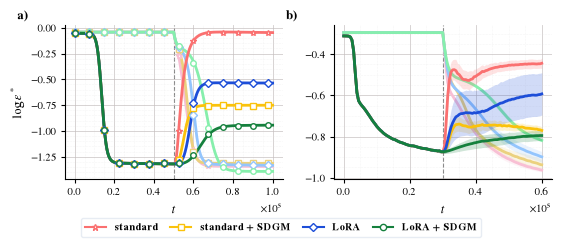

In [10]:
methods_to_plot = [
    "standard",
    "LoRA",
    "Sco-LoRA",
    "Sco-standard",
]

# This will automatically load everything and save it to "for_paper/theory_vs_MNIST.pdf"
plot_theory_vs_real_dataset(
    args=args,
    dataset_name="MNIST",
    methods_to_plot=methods_to_plot
)

# 3. Transfer and forgetting

In [11]:
def extract_metric_at_switch(run, metric_key, P, ODES=False, integration_step=None):
    logs = run["logs"]
    if metric_key not in logs:
        return None

    values = np.array(logs[metric_key]["values"], dtype=float)
    if len(values) == 0:
        return None
    
    if not ODES:
        steps = np.array(logs[metric_key]["steps"])
        idx = np.argmin(np.abs(steps - P))
        return float(values[idx])
    else:
        N = int(run["metadata"]["N"])
        x_axis = (np.arange(len(values)) * integration_step * N)
        idx = np.argmin(np.abs(x_axis - P))
        return float(values[idx])


def extract_metric(run, metric_key, mode="last", ODES=False, integration_step=None):
    logs = run["logs"]
    if metric_key not in logs:
        return None

    values = np.asarray(logs[metric_key]["values"], dtype=float)
    if len(values) == 0:
        return None

    if mode == "last":
        return float(values[-1])
    elif mode == "full":
        meta = run["metadata"]
        P = float(meta["alpha"]) * int(meta["N"])
        if ODES:
            N = int(meta["N"])
            x = np.arange(len(values)) * integration_step * N
        else:
            x = np.asarray(logs[metric_key]["steps"])
        idx = len(values) // 2
        return values[idx:]
    else:
        raise ValueError("mode must be 'last' or 'full'")


def compute_metric(run, metric_type, ODES=False, integration_step=None, extract_mode="last"):
    meta = run["metadata"]
    alpha = float(meta["alpha"])
    N = int(meta["N"])
    P = alpha * N

    switch_loss_1 = extract_metric_at_switch(run, "test_loss_1", P, ODES=ODES, integration_step=integration_step)
    switch_loss_2 = extract_metric_at_switch(run, "test_loss_2", P, ODES=ODES, integration_step=integration_step)

    loss_1 = extract_metric(run, "test_loss_1", extract_mode)
    loss_2 = extract_metric(run, "test_loss_2", extract_mode)

    if (switch_loss_1 is None or switch_loss_2 is None or loss_1 is None or loss_2 is None):
        return None

    if metric_type == "forgetting":
        metric_1 = (np.log10(loss_1) - np.log10(switch_loss_1))
        metric_2 = (np.log10(loss_2) - np.log10(switch_loss_2))
    elif metric_type == "transfer":
        metric_1 = (np.log10(switch_loss_1) - np.log10(loss_1))
        metric_2 = (np.log10(switch_loss_2) - np.log10(loss_2))
    else:
        raise ValueError("metric_type must be 'forgetting' or 'transfer'")

    return metric_1, metric_2


def aggregate_metric(runs, metric_type, task=1, extract_mode="last", ODES=False, integration_step=None,):
    data = []

    for run in runs or []:
        rho = float(run["metadata"]["rho"])

        metrics = compute_metric(run, metric_type, extract_mode=extract_mode, ODES=ODES, integration_step=integration_step,)

        if metrics is None:
            continue

        metric_1, metric_2 = metrics
        value = (metric_1 if task == 1 else metric_2)

        data.append((rho, value))
        
    data.sort(key=lambda x: x[0])

    if len(data) == 0:
        return np.array([]), []
    
    rhos = np.array([x[0] for x in data])

    if extract_mode == "last":
        values = np.array([x[1] for x in data])
    elif extract_mode == "full":
        values = [x[1] for x in data]
    else:
        raise ValueError("extract_mode must be 'last' or 'full'")

    return rhos, values

def plot_metric_vs_rho(ax, runs_sim, extract_mode="last", metric_type="forgetting", marker_sim="o", runs_odes=None, label="", color=None,):

    lw_ODEs = 2.5
    legend_label_size = configs["global"]["legend_label_size"]
    labelspacing = configs["global"]["labelspacing"]
    tick_label_size = configs["global"]["tick_label_size"]
    alpha_sim = configs["global"]["alpha_sim"]
    alpha_ODEs = configs["global"]["alpha_ODEs"]
    markersize_sim = 4.12 if label == "standard" else 3.6
    fontsize_xlabel = 30
    fontsize_ylabel = 30

    ax.tick_params(axis="both", which="major", length=4, width=1.0)
    ax.tick_params(axis="both", labelsize=tick_label_size)
    offset_text = ax.xaxis.get_offset_text()
    offset_text.set_fontsize(tick_label_size)

    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(axis="x", which="minor", length=0)

    task = 1 if metric_type == "forgetting" else 2

    rhos_sim, vals_sim = aggregate_metric(
        runs_sim,
        metric_type,
        task=task,
        extract_mode=extract_mode,
        ODES=False,
        integration_step=args.integration_step,
    )

    ax.plot(
        rhos_sim,
        vals_sim,
        marker=marker_sim,
        markersize=markersize_sim,
        linestyle="",
        alpha=alpha_sim,
        color=color,
        markerfacecolor="white",
        markeredgewidth=1.5,
    )

    if runs_odes:

        rhos_ode, vals_ode = aggregate_metric(
            runs_odes,
            metric_type,
            task=task,
            ODES=True,
            integration_step=args.integration_step,
        )
        ax.plot(
            rhos_ode,
            vals_ode,
            linewidth=lw_ODEs,
            alpha=alpha_ODEs,
            color=color,
            label=label,
        )
    else:
        print("WARNING : NO ODES FOUND")

    ax.set_xlabel("c", fontsize=fontsize_xlabel)

    ax.set_ylabel(metric_type.lower(), fontsize=fontsize_ylabel,)

    # --- Grid Styling ---
    ax.grid(True,which="major",axis="both",linestyle="-",color="#C5BFBF",linewidth=0.8,alpha=0.8,zorder=0,)
    ax.grid(True, which="minor", axis="x", linestyle="-", color="#E0E0E0", linewidth=0.8, alpha=0.6, zorder=0,)

    ax.margins(x=0.02)

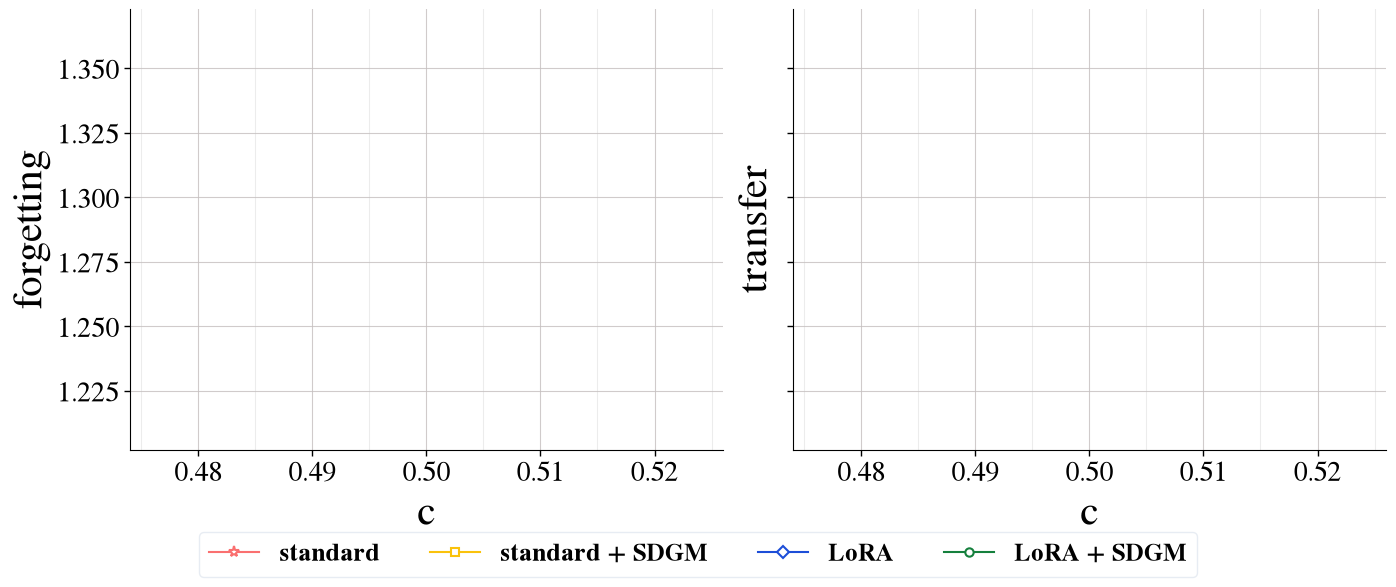

In [12]:
def select_runs(runs, method):
    if runs is []:
        print(f"runs empty for {method}. Leaving")
        return []
    
    return [
        r for r in runs
        if (
            r["metadata"]["method"] == method
            and r["metadata"]["K"] == args.K
            and r["metadata"]["M"] == args.M
            and r["metadata"]["N"] == args.N
            and r["metadata"]["seed"] == args.seed
            and r["metadata"]["alpha"] == args.alpha
            and (r["metadata"]["L"] == args.L if method != "Sco-standard" else True)
        )
    ]

def plot_forgetting_transfer(methods_to_plot=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)
    if methods_to_plot is None:
        target_configs = {k: v for k, v in configs.items() if k != "global"}
    else:
        target_configs = {k: v for k, v in configs.items() if k in methods_to_plot}

    target_rhos = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

    for label, cfg in target_configs.items():
        sim_runs = select_runs(all_sim_runs, label)
        ode_runs = select_runs(all_ode_runs, label)

        sim_runs_filtered = [
            r for r in sim_runs
            if any(np.isclose(float(r["metadata"].get("rho", -1)), target, atol=0.02) for target in target_rhos)
        ]

        plot_metric_vs_rho(
            ax1,
            runs_sim=sim_runs_filtered,
            runs_odes=ode_runs,
            extract_mode="last",
            marker_sim=cfg["marker"],
            metric_type="forgetting",
            label=label,
            color=cfg["colors"][0],
        )

        plot_metric_vs_rho(
            ax2,
            runs_sim=sim_runs_filtered,
            runs_odes=ode_runs,
            extract_mode="last",
            marker_sim=cfg["marker"],
            metric_type="transfer",
            label=label,
            color=cfg["colors"][0],
        )

    legend_handles = [
        mlines.Line2D([], [], color=cfg["colors"][0], marker=cfg["marker"], linestyle='-',
                      markersize=cfg["marker_size"], markerfacecolor="white", markeredgewidth=1.5,
                      label=METHOD_LABELS.get(m, m)) for m, cfg in target_configs.items()]
    
    leg = fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.05),
                     ncol=len(target_configs), frameon=True, edgecolor='#e2e8f0', facecolor='white',fontsize=18)
    
    for text in leg.get_texts():
        text.set_fontweight('bold')

    ymin1, ymax1 = ax1.get_ylim()
    ymin2, ymax2 = ax2.get_ylim()
    unified_ylim = (min(ymin1, ymin2), max(ymax1, ymax2))

    for ax in [ax1, ax2]:
        ax.set_ylim(unified_ylim)
        ax.tick_params(axis='y', which='both', left=True, direction='out', length=4, width=1.0)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    ax2.set_yticklabels([])
    plt.tight_layout()
    plt.savefig("metrics_vs_rho.pdf", bbox_inches='tight')
    plt.show()

methods_to_plot = ["standard", "LoRA", "Sco-LoRA", "Sco-standard"]

path_to_sim = os.path.join(args.path_to_res_folder, f"run_K={args.K}_M={args.M}.npy")
path_to_sim_ODEs = os.path.join(args.path_to_res_folder, f"ODES_K={args.K}_M={args.M}.npy")
all_sim_runs = ExperimentLogger.load_group(path_to_sim)
all_ode_runs = ExperimentLogger.load_group(path_to_sim_ODEs)

plot_forgetting_transfer(methods_to_plot)

# 4. Plasticity-Elasticity Tradeoff

Skipping Sco-standard: no runs found
Skipping LoRA: no runs found
Skipping Sco-LoRA: no runs found


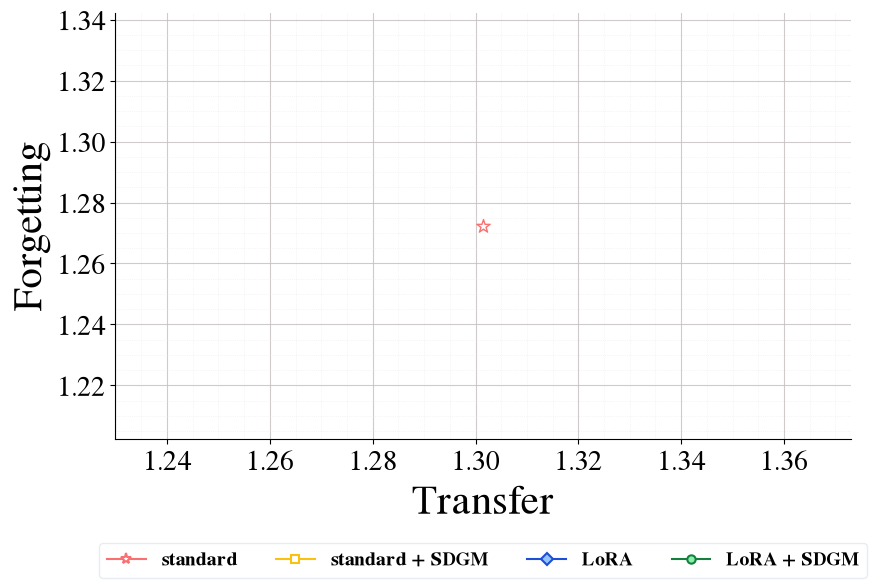

Max number of samples for any rank: 1


In [13]:
all_ode_runs = ExperimentLogger.load_group(path_to_sim_ODEs)

fig, ax = plt.subplots(figsize=(9, 6))

n_samples = 0

for label, cfg in configs.items():
    if label == "global":
        continue
    
    base_color = cfg["colors"][0]
    tradeoff_data = defaultdict(list)
    for run in all_ode_runs:
        meta = run["metadata"]
        if meta["method"] != label:
            continue
        
        L = int(meta["L"])
        transfer_metrics = compute_metric(run, "transfer", ODES=True, integration_step=args.integration_step,)
        forgetting_metrics = compute_metric(run, "forgetting", ODES=True, integration_step=args.integration_step,)
        if transfer_metrics is None or forgetting_metrics is None:
            continue

        tradeoff_data[L].append((transfer_metrics[1], forgetting_metrics[0]))
    if len(tradeoff_data) == 0:
        print(f"Skipping {label}: no runs found")
        continue

    avg_tradeoff_data = {}
    std_tradeoff_data = {}
    for L, values in tradeoff_data.items():
        transfers = np.array([v[0] for v in values])
        forgettings = np.array([v[1] for v in values])
        n = len(values)
        avg_tradeoff_data[L] = (np.mean(transfers), np.mean(forgettings),)

        if n > 1:
            std_tradeoff_data[L] = (np.std(transfers, ddof=1) / np.sqrt(n), np.std(forgettings, ddof=1) / np.sqrt(n),)
        else:
            std_tradeoff_data[L] = (0.0, 0.0)

        n_samples = max(n_samples, n)
    sorted_ranks = sorted(avg_tradeoff_data.keys())
    transfers = [avg_tradeoff_data[L][0] for L in sorted_ranks]
    forgettings = [avg_tradeoff_data[L][1] for L in sorted_ranks]

    if label == "standard":
        ax.scatter(transfers, forgettings, color="white", edgecolors=base_color, 
                   marker=configs["standard"]["marker"], s=100, zorder=5, label=label,)

        for L, x, y in zip(sorted_ranks, transfers, forgettings):
            xerr, yerr = std_tradeoff_data[L]
            ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt="none", ecolor=base_color, alpha=0.35, capsize=3, zorder=2,)

    else:
        ax.plot(transfers, forgettings, linestyle="-", color=base_color, alpha=0.4,)

        cmap = mcolors.LinearSegmentedColormap.from_list(f"grad_{label}", ["#FFFFFF", base_color],)
        norm = mcolors.Normalize(vmin=min(sorted_ranks), vmax=max(sorted_ranks),)
        for L, x, y in zip(sorted_ranks, transfers, forgettings):
            point_color = cmap(norm(L))
            errorbar_color = configs[label]["colors"][0]
            marker=configs[label]["marker"]
            #if label == "Sco-LoRA" and L == args.K:
            #    point_color = configs["Sco-standard"][0]
            #    errorbar_color = configs["Sco-standard"][0]
                
            

            ax.scatter(x, y, color=point_color, edgecolors=base_color, marker=marker, s=100, zorder=3,)
            xerr, yerr = std_tradeoff_data[L]

            ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt="none", ecolor=errorbar_color, alpha=0.35, capsize=3, zorder=2,)

            if label == "Sco-LoRA" and L <= 5:
                ax.annotate(
                    f"L={L}",
                    (x, y),
                    textcoords="offset points",
                    xytext=(0, 10),
                    ha="center",
                    fontsize=13,
                    fontweight="bold",
                    zorder=4,
                )
ax.tick_params(axis='both', which='both', labelsize=20)
ax.set_xlabel("Transfer", fontsize=30)
ax.set_ylabel("Forgetting", fontsize=30)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_handles = [mlines.Line2D([], [], color=cfg["colors"][0], marker=cfg["marker"], linestyle='-',
                        markersize=cfg["marker_size"], markeredgewidth=1.5, label=METHOD_LABELS.get(m, m),
                        markerfacecolor=cfg["colors"][1] if m in ("LoRA", "Sco-LoRA") else "white",)
    for m, cfg in configs.items() if m != "global"]
leg = ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.22), ncol=len(methods_to_plot), frameon=True, edgecolor='#e2e8f0', facecolor='white',fontsize=14)

for text in leg.get_texts():
    text.set_fontweight('bold')

ax.minorticks_on()
ax.tick_params(axis='both', which='minor', length=0)
ax.grid(True, which='major', axis='both', linestyle='-', color="#C5BFBF", linewidth=0.8, alpha=0.8, zorder=0)
ax.grid(True, which='minor', axis='both', linestyle=':', color='#E0E0E0', linewidth=0.5, alpha=0.6, zorder=0)
plt.tight_layout()
#fig.subplots_adjust(bottom=0.18) 
plt.savefig("for_paper/transfer_forgetting.pdf", bbox_inches='tight')
plt.show()

print(f"Max number of samples for any rank: {n_samples}")

# Fig 3

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.colors as mcolors
from collections import defaultdict

def plot_forgetting_transfer_axes(ax1, ax2, target_configs, all_sim_runs, all_ode_runs, target_rhos=None):
    """
    Plots Panel (a): Forgetting vs c and Panel (b): Transfer vs c.
    """
    if target_rhos is None:
        target_rhos = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])

    for label, cfg in target_configs.items():
        sim_runs = select_runs(all_sim_runs, label)
        ode_runs = select_runs(all_ode_runs, label)

        sim_runs_filtered = [
            r for r in sim_runs
            if any(np.isclose(float(r["metadata"].get("rho", -1)), target, atol=0.02) for target in target_rhos)
        ]

        # Panel (a)
        plot_metric_vs_rho(
            ax1,
            runs_sim=sim_runs_filtered,
            runs_odes=ode_runs,
            extract_mode="last",
            marker_sim=cfg["marker"],
            metric_type="forgetting",
            label=label,
            color=cfg["colors"][0],
        )

        # Panel (b)
        plot_metric_vs_rho(
            ax2,
            runs_sim=sim_runs_filtered,
            runs_odes=ode_runs,
            extract_mode="last",
            marker_sim=cfg["marker"],
            metric_type="transfer",
            label=label,
            color=cfg["colors"][0],
        )

    ax1.set_xlabel("c")
    ax1.set_ylabel("Forgetting")
    ax2.set_xlabel("c")
    ax2.set_ylabel("Transfer")
    ax2.set_ylim(ax1.get_ylim())


def plot_tradeoff_axis(ax, target_configs, all_ode_runs, args):
    """
    Plots Panel (c): Forgetting vs. Transfer tradeoff.
    """

    for label, cfg in target_configs.items():
        print(f"plotting for {label} procedure")
        if label == "global":
            continue
        
        base_color = cfg["colors"][0]
        tradeoff_data = defaultdict(list)
        
        for run in all_ode_runs:
            meta = run["metadata"]
            if meta["method"] != label:
                continue
            
            L = int(meta["L"])
            transfer_metrics = compute_metric(run, "transfer", ODES=True, integration_step=args.integration_step)
            forgetting_metrics = compute_metric(run, "forgetting", ODES=True, integration_step=args.integration_step)
            if transfer_metrics is None or forgetting_metrics is None:
                continue

            tradeoff_data[L].append((transfer_metrics[1], forgetting_metrics[0]))

        if len(tradeoff_data) == 0:
            print(f"Skipping {label}: no runs found")
            continue

        avg_tradeoff_data = {}
        std_tradeoff_data = {}
        for L, values in tradeoff_data.items():
            transfers = np.array([v[0] for v in values])
            forgettings = np.array([v[1] for v in values])
            print(f"number of data poinnts for rank={L} : {len(values)}")
            n = len(values)
            avg_tradeoff_data[L] = (np.mean(transfers), np.mean(forgettings))

            if n > 1:
                std_tradeoff_data[L] = (np.std(transfers, ddof=1) / np.sqrt(n), np.std(forgettings, ddof=1) / np.sqrt(n))
            else:
                std_tradeoff_data[L] = (0.0, 0.0)

        sorted_ranks = sorted(avg_tradeoff_data.keys())
        transfers = [avg_tradeoff_data[L][0] for L in sorted_ranks]
        forgettings = [avg_tradeoff_data[L][1] for L in sorted_ranks]

        if label == "standard":
            ax.scatter(
                transfers, forgettings, color="white", edgecolors=base_color,
                marker=cfg["marker"], s=17, zorder=5, label=label
            )
            for L, x, y in zip(sorted_ranks, transfers, forgettings):
                xerr, yerr = std_tradeoff_data[L]
                ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt="none", ecolor=base_color, alpha=0.35, capsize=2, zorder=2)

        else:
            ax.plot(transfers, forgettings, linestyle="-", color=base_color, alpha=0.4)
            cmap = mcolors.LinearSegmentedColormap.from_list(f"grad_{label}", ["#FFFFFF", base_color])
            norm = mcolors.Normalize(vmin=min(sorted_ranks), vmax=max(sorted_ranks))

            for L, x, y in zip(sorted_ranks, transfers, forgettings):
                point_color = cmap(norm(L))
                errorbar_color = cfg["colors"][0]
                marker = cfg["marker"]

                ax.scatter(x, y, color=point_color, edgecolors=base_color, marker=marker, s=13, zorder=3)
                xerr, yerr = std_tradeoff_data[L]
                ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt="none", ecolor=errorbar_color, alpha=0.35, capsize=2, zorder=2)

                #if label == "Sco-LoRA" and L <= 5:
                #    ax.annotate(
                #        f"L={L}",
                #        (x, y),
                #        textcoords="offset points",
                #        xytext=(0, 3),
                #        ha="center",
                #        fontsize=4,
                #        fontweight="bold",
                #        zorder=4,
                #    )

    ax.set_xlabel("Transfer")
    ax.set_ylabel("Forgetting")
    return n

[{'metadata': {'N': 1000, 'M': 5, 'K': 10, 'rho': 0.5, 'dataset': 'synthetic', 'method': 'standard', 'scoring_method': 'SDGM', 'rows_to_freeze': 5, 'informed_initialization': False, 'alpha': 50, 'gamma': 1, 'L': 5, 'alpha_W': 0.5, 'alpha_H': 0.5, 'alpha_a': 0.5, 'alpha_b': 0.5, 'teacher_initialization': 'committee', 'teacher_hl_initialization': 'ungraded', 'teacher_activation_function': 'erf', 'student_activation_function': 'erf', 'student_initialization': 'unspecializing', 'seed': 1001}, 'logs': {'test_loss_1': {'steps': array([   0,    0,    1, ..., 1997, 1998, 1999], shape=(2001,)), 'values': array([0.8835537241785728, 0.8835537241785728, 0.8835533991376859, ...,
       0.8969592475095631, 0.8969350063604621, 0.8969107773461447],
      shape=(2001,), dtype=object)}, 'test_loss_2': {'steps': array([   0,    0,    1, ..., 1997, 1998, 1999], shape=(2001,)), 'values': array([0.9061853512183771, 0.9061853512183771, 0.9061853237328751, ...,
       0.04525688973046402, 0.04525659304537645,

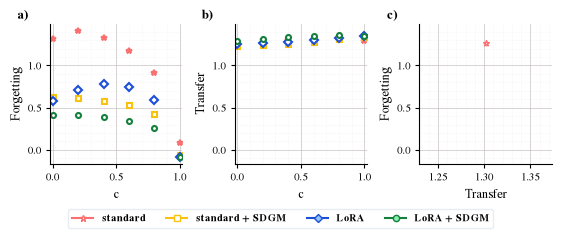

In [15]:
def generate_iclr_figure(methods_to_plot,args):
    target_configs = {k: v for k, v in configs.items() if k in methods_to_plot and k != "global"}
    
    path_to_similarity_sim = os.path.join(args.path_to_res_folder, f"fig3_forgetting+transfer_f_similarity/run_K={args.K}_M={args.M}.npy")
    path_to_sim_similarity_ODEs = os.path.join(args.path_to_res_folder, f"forgetting+transfer_f_similarity/ODES_K={args.K}_M={args.M}.npy")

    all_sim_runs_similarity = ExperimentLogger.load_group(path_to_similarity_sim)
    all_ode_runs_similarity = ExperimentLogger.load_group(path_to_sim_similarity_ODEs)


    # Define uniform target font sizes for ICLR
    FONT_LABEL = 9
    FONT_TICK = 7.5

    # Set base rcParams
    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 8,
        "axes.labelsize": FONT_LABEL,
        "axes.titlesize": FONT_LABEL,
        "xtick.labelsize": FONT_TICK,
        "ytick.labelsize": FONT_TICK,
    })

    # Create 1x3 panel figure
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(5.5, 2.0), layout='constrained')
    subplot_labels = ["a)", "b)", "c)"]
    axes = [ax1, ax2, ax3]

    # 1. Render Panels (a) and (b)
    plot_forgetting_transfer_axes(ax1, ax2, target_configs, all_sim_runs_similarity, all_ode_runs_similarity)

    # 2. Render Panel (c)
    path_to_sim = os.path.join(args.path_to_res_folder, f"run_K={args.K}_M={args.M}.npy")
    path_to_sim_ODEs = os.path.join(args.path_to_res_folder, f"ODES_K={args.K}_M={args.M}.npy")

    all_sim_runs = ExperimentLogger.load_group(path_to_sim)
    all_ode_runs = ExperimentLogger.load_group(path_to_sim_ODEs)
    print(all_ode_runs)
    n_samples = plot_tradeoff_axis(ax3, target_configs, all_ode_runs, args)

    # 3. OVERRIDE FONT SIZES (Fixes hardcoded sizes from plot_metric_vs_rho)
    for ax, panel_label in zip(axes, subplot_labels):
        ax.set_title(panel_label, x=-0.25, ha="left", fontsize=9, fontweight="bold", pad=4)
        ax.xaxis.label.set_size(FONT_LABEL)
        ax.yaxis.label.set_size(FONT_LABEL)
        
        # Reset tick font sizes
        ax.tick_params(axis='both', which='major', labelsize=FONT_TICK, length=3, width=0.8, direction='out')
        ax.tick_params(axis='both', which='minor', length=0)
        
        # Reset spines & grids
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.minorticks_on()
        ax.grid(True, which='major', axis='both', linestyle='-', color="#C5BFBF", linewidth=0.6, alpha=0.8, zorder=0)
        ax.grid(True, which='minor', axis='both', linestyle=':', color='#E0E0E0', linewidth=0.4, alpha=0.6, zorder=0)

    # 4. Horizontal Bottom Legend
    legend_handles = [
        mlines.Line2D(
            [], [], 
            color=cfg["colors"][0], 
            marker=cfg["marker"], 
            linestyle='-',
            markersize=4.5, 
            markeredgewidth=1.0, 
            label=METHOD_LABELS.get(m, m),
            markerfacecolor=cfg["colors"][1] if len(cfg["colors"]) > 1 and m in ("LoRA", "Sco-LoRA") else "white"
        )
        for m, cfg in target_configs.items()
    ]

    leg = fig.legend(
        handles=legend_handles, 
        loc='lower center', 
        bbox_to_anchor=(0.5, -0.14), 
        ncol=len(target_configs), 
        frameon=True, 
        edgecolor='#e2e8f0', 
        facecolor='white',
        fontsize=7.5
    )

    for text in leg.get_texts():
        text.set_fontweight('bold')

    ax3.set_ylim(ax1.get_ylim())
    os.makedirs("for_paper", exist_ok=True)
    plt.savefig("for_paper/transfer_forgetting.pdf", bbox_inches='tight', pad_inches=0.02)
    plt.show()

# --- Execution ---
methods_to_plot = ["standard", "LoRA", "Sco-LoRA", "Sco-standard"]

generate_iclr_figure(methods_to_plot, args)

# Appendix

In [16]:
def plot_all_protocols_axis(
    ax,
    all_sim_runs,
    all_ode_runs,
    target_configs,
    args,
):
    """
    Panel (a): Training losses for all protocols.

    Synthetic:
        ODE = continuous line
        Simulation = markers

    Real datasets:
        Mean +/- std over seeds
    """

    lw_task1 = 2.0
    lw_task2 = 2.0
    markevery_sim = 1

    is_synthetic = (args.dataset == "synthetic")

    for label, cfg in target_configs.items():

        if is_synthetic:

            # --------------------------------------------------
            # Synthetic: single simulation + single ODE
            # --------------------------------------------------
            sim_run = select_single_trajectory_run(
                all_sim_runs, args, label
            )
            ode_run = select_single_trajectory_run(
                all_ode_runs, args, label
            )

            # ODE
            if ode_run is not None:

                ode_logs = ode_run["logs"]

                if (
                    "test_loss_1" in ode_logs
                    and "test_loss_2" in ode_logs
                ):

                    loss_ref_1 = np.asarray(
                        ode_logs["test_loss_1"]["values"],
                        dtype=np.float64
                    )

                    loss_ref_2 = np.asarray(
                        ode_logs["test_loss_2"]["values"],
                        dtype=np.float64
                    )

                    t_span = (
                        np.arange(len(loss_ref_1))
                        * args.integration_step
                        * args.N
                    )

                    ax.plot(
                        t_span,
                        np.log10(loss_ref_1),
                        color=cfg["colors"][0],
                        linestyle="-",
                        lw=lw_task1,
                        alpha=0.7,
                        zorder=3,
                    )

                    ax.plot(
                        t_span,
                        np.log10(loss_ref_2),
                        color=cfg["colors"][1],
                        linestyle="-",
                        lw=lw_task2,
                        alpha=0.7,
                        zorder=1,
                    )

            # Simulation
            if sim_run is not None and "logs" in sim_run:

                sim_logs = sim_run["logs"]

                if (
                    "test_loss_1" in sim_logs
                    and "test_loss_2" in sim_logs
                ):

                    steps = np.asarray(
                        sim_logs["test_loss_1"]["steps"]
                    )

                    ax.plot(
                        steps,
                        np.log10(
                            np.asarray(
                                sim_logs["test_loss_1"]["values"],
                                dtype=np.float64
                            )
                        ),
                        linestyle="None",
                        marker=cfg["marker"],
                        markevery=markevery_sim,
                        color=cfg["colors"][0],
                        markerfacecolor="white",
                        markersize=cfg["marker_size"],
                        markeredgewidth=1.0,
                        alpha=1.0,
                        zorder=4,
                    )

                    ax.plot(
                        steps,
                        np.log10(
                            np.asarray(
                                sim_logs["test_loss_2"]["values"],
                                dtype=np.float64
                            )
                        ),
                        linestyle="None",
                        marker=cfg["marker"],
                        markevery=markevery_sim,
                        color=cfg["colors"][1],
                        markerfacecolor="white",
                        markersize=cfg["marker_size"],
                        markeredgewidth=1.0,
                        alpha=1.0,
                        zorder=2,
                    )

        else:

            # --------------------------------------------------
            # Real datasets: mean +/- std over seeds
            # --------------------------------------------------
            matching_runs = select_all_matching_runs(
                all_sim_runs,
                args,
                label
            )

            if not matching_runs:
                continue

            loss1_runs = []
            loss2_runs = []
            ref_steps = None

            for r in matching_runs:

                sim_logs = r.get("logs", {})

                if (
                    "test_loss_1" not in sim_logs
                    or "test_loss_2" not in sim_logs
                ):
                    continue

                if ref_steps is None:
                    ref_steps = np.asarray(
                        sim_logs["test_loss_1"]["steps"]
                    )

                loss1_runs.append(
                    np.log10(
                        np.asarray(
                            sim_logs["test_loss_1"]["values"],
                            dtype=np.float64
                        )
                    )
                )

                loss2_runs.append(
                    np.log10(
                        np.asarray(
                            sim_logs["test_loss_2"]["values"],
                            dtype=np.float64
                        )
                    )
                )

            if not loss1_runs:
                continue

            loss1_arr = np.asarray(loss1_runs)
            loss2_arr = np.asarray(loss2_runs)

            mean1 = np.mean(loss1_arr, axis=0)
            std1 = np.std(loss1_arr, axis=0)

            mean2 = np.mean(loss2_arr, axis=0)
            std2 = np.std(loss2_arr, axis=0)

            ax.plot(
                ref_steps,
                mean1,
                color=cfg["colors"][0],
                lw=lw_task1,
                zorder=4,
            )

            ax.fill_between(
                ref_steps,
                mean1 - std1,
                mean1 + std1,
                color=cfg["colors"][0],
                alpha=0.20,
                zorder=3,
            )

            ax.plot(
                ref_steps,
                mean2,
                color=cfg["colors"][1],
                lw=lw_task2,
                zorder=2,
            )

            ax.fill_between(
                ref_steps,
                mean2 - std2,
                mean2 + std2,
                color=cfg["colors"][1],
                alpha=0.20,
                zorder=1,
            )

    # ----------------------------------------------------------
    # Task switch
    # ----------------------------------------------------------
    if args.dataset == "synthetic":
        P_time = args.N * args.alpha

    elif args.dataset == "MNIST":
        P_time = 30000

    elif args.dataset in ["CIFAR", "fMNIST"]:
        P_time = 12000

    else:
        raise ValueError("NOT IMPLEMENTED")

    ax.axvline(
        P_time,color="grey", lw=0.8, linestyle="--", zorder=0)

    # ----------------------------------------------------------
    # Formatting
    # ----------------------------------------------------------
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))

    ax.xaxis.set_major_formatter(formatter)

    ax.set_xlabel(r"$t$")
    ax.set_ylabel(r"$\log \epsilon^*$")

    return ax

def plot_forgetting_transfer_axes(
    ax_forgetting,
    ax_transfer,
    target_configs,
    all_sim_runs,
    all_ode_runs,
    args,
    target_rhos=None,
):
    if target_rhos is None:
        target_rhos = np.array(
            [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
        )

    for label, cfg in target_configs.items():

        sim_runs = select_runs(all_sim_runs, label)
        ode_runs = select_runs(all_ode_runs, label)

        sim_runs_filtered = [
            r for r in sim_runs
            if any(
                np.isclose(
                    float(r["metadata"].get("rho", -1)),
                    target,
                    atol=0.02,
                )
                for target in target_rhos
            )
        ]

        # ----------------------------------------------
        # Forgetting
        # ----------------------------------------------
        plot_metric_vs_rho(
            ax_forgetting,
            runs_sim=sim_runs_filtered,
            runs_odes=ode_runs,
            extract_mode="last",
            marker_sim=cfg["marker"],
            metric_type="forgetting",
            label=label,
            color=cfg["colors"][0],
        )

        # ----------------------------------------------
        # Transfer
        # ----------------------------------------------
        plot_metric_vs_rho(
            ax_transfer,
            runs_sim=sim_runs_filtered,
            runs_odes=ode_runs,
            extract_mode="last",
            marker_sim=cfg["marker"],
            metric_type="transfer",
            label=label,
            color=cfg["colors"][0],
        )

    ax_forgetting.set_xlabel(r"$\rho$")
    ax_forgetting.set_ylabel("Forgetting")

    ax_transfer.set_xlabel(r"$\rho$")
    ax_transfer.set_ylabel("Transfer")

    return ax_forgetting, ax_transfer


# Fig 3

In [17]:
def generate_combined_figure(methods_to_plot=None):

    # ==========================================================
    # CONFIGS
    # ==========================================================
    if methods_to_plot is None:
        target_configs = {
            k: v for k, v in configs.items()
            if k != "global"
        }
    else:
        target_configs = {
            k: v for k, v in configs.items()
            if k in methods_to_plot
        }

    # ==========================================================
    # LOAD DATA
    # ==========================================================
    path_to_sim = os.path.join(
        args.path_to_res_folder,
        f"run_K={args.K}_M={args.M}.npy"
    )

    path_to_sim_ODEs = os.path.join(
        args.path_to_res_folder,
        f"ODES_K={args.K}_M={args.M}.npy"
    )

    #all_sim_runs = ExperimentLogger.load_group(path_to_sim)
    #all_ode_runs = ExperimentLogger.load_group(path_to_sim_ODEs)

    # ==========================================================
    # FIGURE
    # ==========================================================
    FONT_LABEL = 9
    FONT_TICK = 7.5

    plt.rcParams.update({
        "font.family": "serif",
        "font.size": 8,
        "axes.labelsize": FONT_LABEL,
        "axes.titlesize": FONT_LABEL,
        "xtick.labelsize": FONT_TICK,
        "ytick.labelsize": FONT_TICK,
    })

    fig, (ax1, ax2, ax3) = plt.subplots(
        1,
        3,
        figsize=(5.8, 2.05),
    )

    # ==========================================================
    # PANEL (a): PROTOCOLS
    # ==========================================================
    plot_all_protocols_axis(
        ax1,
        all_sim_runs,
        all_ode_runs,
        target_configs,
        args,
    )

    # ==========================================================
    # PANELS (b,c): FORGETTING + TRANSFER
    #
    # THIS IS COPIED DIRECTLY FROM YOUR WORKING FUNCTION
    # ==========================================================

    target_rhos = np.array([
        0.0,
        0.2,
        0.4,
        0.6,
        0.8,
        1.0
    ])

    for label, cfg in target_configs.items():

        sim_runs = select_runs(
            all_sim_runs,
            label
        )

        ode_runs = select_runs(
            all_ode_runs,
            label
        )

        sim_runs_filtered = [
            r for r in sim_runs
            if any(
                np.isclose(
                    float(r["metadata"].get("rho", -1)),
                    target,
                    atol=0.02
                )
                for target in target_rhos
            )
        ]

        # ------------------------------------------------------
        # PANEL (b): FORGETTING
        # ------------------------------------------------------
        plot_metric_vs_rho(
            ax2,
            runs_sim=sim_runs_filtered,
            runs_odes=ode_runs,
            extract_mode="last",
            marker_sim=cfg["marker"],
            metric_type="forgetting",
            label=label,
            color=cfg["colors"][0],
        )

        # ------------------------------------------------------
        # PANEL (c): TRANSFER
        # ------------------------------------------------------
        plot_metric_vs_rho(
            ax3,
            runs_sim=sim_runs_filtered,
            runs_odes=ode_runs,
            extract_mode="last",
            marker_sim=cfg["marker"],
            metric_type="transfer",
            label=label,
            color=cfg["colors"][0],
        )

    # ==========================================================
    # PANEL LABELS
    # ==========================================================
    for ax, label in zip(
        [ax1, ax2, ax3],
        ["a)", "b)", "c)"]
    ):
        ax.set_title(
            label,
            loc="left",
            fontsize=9,
            fontweight="bold",
            pad=4,
        )

    # ==========================================================
    # FORMATTING
    # ==========================================================
    for ax in [ax1, ax2, ax3]:

        ax.tick_params(
            axis="both",
            which="major",
            labelsize=FONT_TICK,
            length=3,
            width=0.8,
            direction="out",
        )

        ax.tick_params(
            axis="both",
            which="minor",
            length=0,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.xaxis.label.set_size(FONT_LABEL)
        ax.yaxis.label.set_size(FONT_LABEL)

        ax.grid(
            True,
            which="major",
            axis="both",
            linestyle="-",
            color="#C5BFBF",
            linewidth=0.6,
            alpha=0.8,
            zorder=0,
        )

        ax.grid(
            True,
            which="minor",
            axis="both",
            linestyle=":",
            color="#E0E0E0",
            linewidth=0.4,
            alpha=0.6,
            zorder=0,
        )

    # ==========================================================
    # LEFT PANEL: SCIENTIFIC X AXIS
    # ================================================= args.gamma = np.sqrt(args.K)=========
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((0, 0))

    ax1.xaxis.set_major_formatter(formatter)
    ax1.xaxis.get_offset_text().set_fontsize(FONT_TICK)

    # ==========================================================
    # MIDDLE / RIGHT LABELS
    # ==========================================================
    ax2.set_xlabel(r"c")
    ax2.set_ylabel("Forgetting")

    ax3.set_xlabel(r"c")
    ax3.set_ylabel("Transfer")

    # ==========================================================
    # SAME Y RANGE FOR FORGETTING / TRANSFER
    # ==========================================================
    ymin1, ymax1 = ax2.get_ylim()
    ymin2, ymax2 = ax3.get_ylim()

    unified_ylim = (
        min(ymin1, ymin2),
        max(ymax1, ymax2),
    )

    ax2.set_ylim(unified_ylim)
    ax3.set_ylim(unified_ylim)

    # Don't show duplicate y tick labels
    ax3.set_yticklabels([])

    # ==========================================================
    # SHARED LEGEND
    # ==========================================================
    legend_handles = [
        mlines.Line2D(
            [],
            [],
            color=cfg["colors"][0],
            marker=cfg["marker"],
            linestyle="-",
            markersize=4.5,
            markerfacecolor="white",
            markeredgewidth=1.0,
            label=METHOD_LABELS.get(m, m),
        )
        for m, cfg in target_configs.items()
    ]

    leg = fig.legend(
        handles=legend_handles,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.22),
        ncol=len(target_configs),
        frameon=True,
        edgecolor="#e2e8f0",
        facecolor="white",
        fontsize=7.5,
    )

    for text in leg.get_texts():
        text.set_fontweight("bold")

    # ==========================================================
    # SAVE
    # ==========================================================
    os.makedirs("for_paper", exist_ok=True)

    plt.savefig(
        "for_paper/protocols_forgetting_transfer.pdf",
        bbox_inches="tight",
        pad_inches=0.02,
    )

    plt.show()

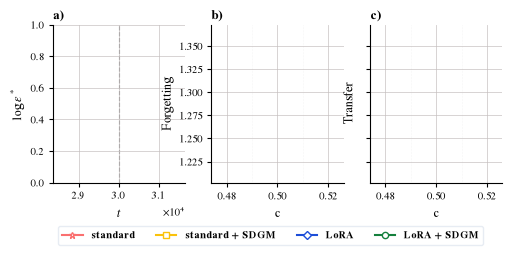

In [18]:
methods_to_plot = [
    "standard",
    "LoRA",
    "Sco-LoRA",
    "Sco-standard",
]

generate_combined_figure(methods_to_plot)

# 5. Order parameters

# Plot Q as a function of rho

In [19]:
def aggregate_student_norm(
    runs,
    method,
):
    """
    Aggregate the absolute value of the student norm diagonal as a function of rho.
    Supports 'standard', 'LoRA', and 'Sco-LoRA'.
    """
    data = []
    for run in runs or []:
        meta = run["metadata"]
        rho = float(meta["rho"])
        logs = run["logs"]

        if "Q" not in logs:
            continue

        Q = np.asarray(logs["Q"]["values"][-1], dtype=float)

        m_lower = method.lower()
        if m_lower == "standard":
            norm = Q

        elif m_lower in ["lora", "sco-lora"]:
            if "B" not in logs or "Phi" not in logs:
                continue

            B = np.asarray(logs["B"]["values"][-1], dtype=float)
            Phi = np.asarray(logs["Phi"]["values"][-1], dtype=float)
            
            # Safely check for Xi or default to zero array if not logged
            Xi = np.asarray(logs["Xi"]["values"][-1], dtype=float) if "Xi" in logs else np.zeros_like(B)

            gamma = float(meta["gamma"])
            L = int(meta["L"])

            coeff = gamma / np.sqrt(L)
            
            # If Sco-LoRA has a distinct formulation tweak, you can branch it here. 
            # Otherwise, it shares the expanded adapter norm formulation:
            norm = Q + coeff * (Xi @ B.T) + coeff * (B @ Xi.T) + (coeff**2) * (B @ Phi @ B.T)
        else:
            norm = Q

        # Absolute value
        norm = np.abs(np.asarray(norm, dtype=float))

        # Extract diagonal
        if norm.ndim == 2:
            norm = np.diagonal(norm)
        elif norm.ndim == 0:
            norm = np.array([float(norm)])
        elif norm.ndim != 1:
            norm = norm.flatten()

        data.append((rho, norm))

    data.sort(key=lambda x: x[0])

    if len(data) == 0:
        return np.array([]), np.array([])

    rhos = np.array([x[0] for x in data])
    values_matrix = np.array([x[1] for x in data])

    return rhos, values_matrix

def aggregate_readout(
    runs,
    op_key,
):
    """
    Aggregate the absolute final values of a readout order parameter
    (Ha or Hb) as a function of rho.
    """
    data = []

    for run in runs or []:
        meta = run["metadata"]
        rho = float(meta["rho"])
        logs = run["logs"]

        if op_key not in logs:
            continue

        # Final value
        values = np.asarray(
            logs[op_key]["values"][-1],
            dtype=float,
        )

        # Take absolute value of the quantities being plotted
        values = np.abs(values)

        # Convert to 1D
        if values.ndim == 0:
            values = np.array([float(values)])
        else:
            values = values.flatten()

        data.append((rho, values))

    # Sort by task similarity
    data.sort(key=lambda x: x[0])

    if len(data) == 0:
        return np.array([]), np.array([])

    rhos = np.array([x[0] for x in data])
    values_matrix = np.array([x[1] for x in data])

    return rhos, values_matrix

# =============================================================
# PLOT STUDENT NORM
# =============================================================

def plot_student_norm_vs_rho(
    ax,
    runs_sim,
    method,
    marker_sim="o",
    runs_odes=None,
    label="",
    color=None,
):
    lw_ODEs = 2.5
    tick_label_size = 13
    alpha_sim = 0.9
    alpha_ODEs = 0.7
    markersize_sim = 6
    fontsize_xlabel = 18
    fontsize_ylabel = 18

    ax.tick_params(axis="both", which="both", length=0)
    ax.tick_params(axis="both", labelsize=tick_label_size)

    # =========================================================
    # 1. Simulation
    # =========================================================

    rhos_sim, vals_sim = aggregate_student_norm(
        runs_sim,
        method=method,
    )

    if vals_sim.size > 0:

        if vals_sim.ndim == 1:
            vals_sim = vals_sim[:, np.newaxis]

        num_components = vals_sim.shape[1]
        cmap = cm.viridis

        for comp_idx in range(num_components):
            t = comp_idx / max(1, num_components - 1)
            line_color = cmap(t)

            ax.plot(
                rhos_sim,
                vals_sim[:, comp_idx],
                marker=marker_sim,
                markersize=markersize_sim,
                linestyle="",
                alpha=alpha_sim,
                color=line_color,
                markerfacecolor="white",
                markeredgewidth=1.2,
            )

    # =========================================================
    # 2. ODE theory
    # =========================================================

    if runs_odes:

        rhos_ode, vals_ode = aggregate_student_norm(
            runs_odes,
            method=method,
        )

        if vals_ode.size > 0:

            if vals_ode.ndim == 1:
                vals_ode = vals_ode[:, np.newaxis]

            num_components = vals_ode.shape[1]
            cmap = cm.viridis

            for comp_idx in range(num_components):
                t = comp_idx / max(1, num_components - 1)
                line_color = cmap(t)

                ax.plot(
                    rhos_ode,
                    vals_ode[:, comp_idx],
                    linewidth=lw_ODEs,
                    alpha=alpha_ODEs,
                    color=line_color,
                    label=label if comp_idx == num_components - 1 else "",
                )

    else:
        print(f"WARNING: NO ODES FOUND for {method}")

    ax.set_xlabel(r"$c$", fontsize=fontsize_xlabel)
    ax.set_ylabel("Hidden-layer Student Norm", fontsize=fontsize_ylabel)
    ax.grid(True, alpha=0.3)
    ax.margins(x=0.02)


# =============================================================
# PLOT READOUT WEIGHT (Ha / Hb)
# =============================================================

def plot_readout_vs_rho(
    ax,
    runs_sim,
    runs_odes,
    method,
    op_key,
    marker_sim="o",
    label="",
    color_palette=None,  # Accepts custom list or defaults to PASTEL_PALETTE
):
    lw_ODEs = 2.5
    tick_label_size = 20
    alpha_sim = 0.9
    alpha_ODEs = 1
    markersize_sim = 6

    # Default to PASTEL_PALETTE if no palette is provided
    palette = color_palette if color_palette is not None else PASTEL_PALETTE

    ax.tick_params(axis="both", which="both", length=0)
    ax.tick_params(axis="both", labelsize=tick_label_size)

    # =========================================================
    # 1. Simulation
    # =========================================================
    rhos_sim, vals_sim = aggregate_readout(
        runs_sim,
        op_key=op_key,
    )

    if vals_sim.size > 0:
        if vals_sim.ndim == 1:
            vals_sim = vals_sim[:, np.newaxis]

        num_components = vals_sim.shape[1]

        for comp_idx in range(num_components):
            # Select color from palette safely using modulo
            line_color = palette[comp_idx % len(palette)]

            ax.plot(
                rhos_sim,
                vals_sim[:, comp_idx],
                marker=marker_sim,
                markersize=markersize_sim,
                linestyle="",
                alpha=alpha_sim,
                color=line_color,
                markerfacecolor="white",
                markeredgewidth=1.2,
            )

    # =========================================================
    # 2. ODE theory
    # =========================================================
    if runs_odes:
        rhos_ode, vals_ode = aggregate_readout(
            runs_odes,
            op_key=op_key,
        )

        if vals_ode.size > 0:
            if vals_ode.ndim == 1:
                vals_ode = vals_ode[:, np.newaxis]

            num_components = vals_ode.shape[1]

            for comp_idx in range(num_components):
                # Select color from palette safely using modulo
                line_color = palette[comp_idx % len(palette)]

                ax.plot(
                    rhos_ode,
                    vals_ode[:, comp_idx],
                    linewidth=lw_ODEs,
                    alpha=alpha_ODEs,
                    color=line_color,
                    label=label if comp_idx == num_components - 1 else "",
                )

    else:
        print(f"WARNING: NO ODES FOUND for {op_key}")

    # =========================================================
    # Formatting
    # =========================================================
    ax.set_xlabel(r"$c$", fontsize=30)
    #ylabel = r"$|\mathbf{h}^\dagger|$" if op_key == "h1" else r"$|\mathbf{h}^\ddagger|$"
    ylabel = r"$|\mathbf{h}^\dagger|$" if op_key == "h1" else r"$|\mathbf{h}^\ddagger|$"
    ax.set_ylabel(ylabel, fontsize=30)
    ax.grid(True, alpha=0.3)
    ax.margins(x=0.02)

NameError: name 'PASTEL_PALETTE' is not defined

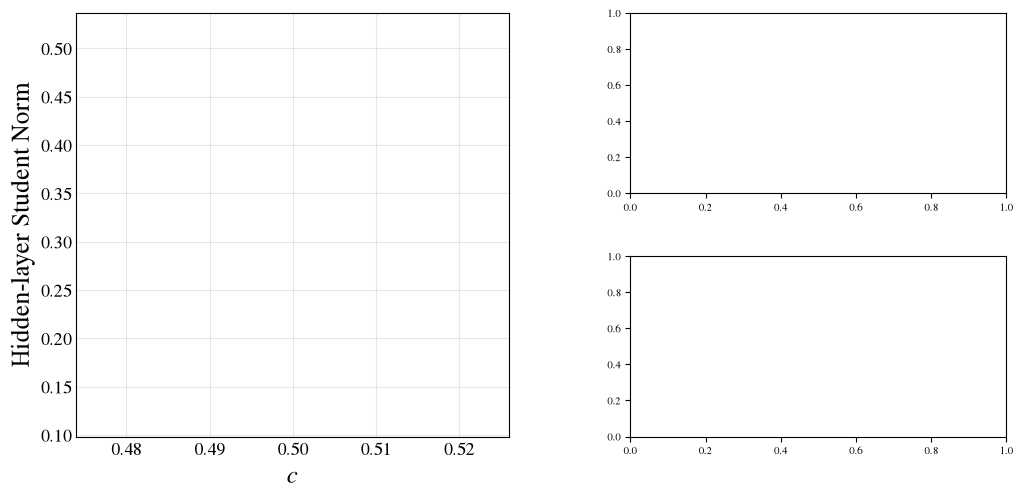

In [20]:
selected_training_type = "standard" 

fig = plt.figure(figsize=(12, 5.5))
#fig.suptitle(f"Training Architecture: {selected_training_type}", fontsize=20, y=0.98)

gs = fig.add_gridspec(2, 2, width_ratios=[1.15, 1], height_ratios=[1, 1], wspace=0.30, hspace=0.35)

ax_norm = fig.add_subplot(gs[:, 0])
ax_Ha = fig.add_subplot(gs[0, 1])
ax_Hb = fig.add_subplot(gs[1, 1], sharex=ax_Ha)

# Fetch runs matching the selected training type instead of blindly looping over all config keys
sim_runs = select_runs(all_sim_runs, selected_training_type)
ode_runs = select_runs(all_ode_runs, selected_training_type)

# If your configs dict holds visual styling properties (like markers/colors) for the training types:
cfg = configs.get(selected_training_type, {"colors": ["#1f77b4"], "marker": "o"})
color = cfg["colors"][0]
marker = cfg["marker"]
plot_student_norm_vs_rho(
    ax_norm, 
    runs_sim=sim_runs, 
    runs_odes=ode_runs, 
    method=selected_training_type, 
    marker_sim=marker, 
    label=selected_training_type, 
    color=color
)
plot_readout_vs_rho(
    ax_Ha, 
    runs_sim=sim_runs, 
    runs_odes=ode_runs, 
    method=selected_training_type, 
    op_key="h1", 
    marker_sim=marker, 
    label=selected_training_type, 
    #color=color
)
plot_readout_vs_rho(
    ax_Hb, 
    runs_sim=sim_runs, 
    runs_odes=ode_runs, 
    method=selected_training_type, 
    op_key="h2", 
    marker_sim=marker, 
    label=selected_training_type, 
    #color=color
)

ax_Ha.tick_params(axis="x", labelbottom=False)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("student_norm_and_readout_vs_rho.pdf", bbox_inches="tight")
plt.show()

NameError: name 'PASTEL_PALETTE' is not defined

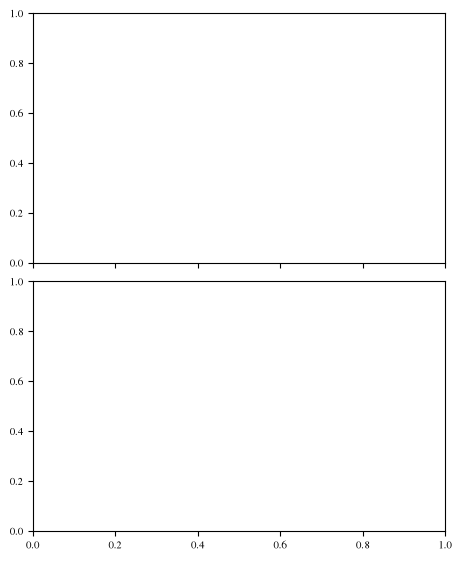

In [21]:
PALETTE_VIRIDIS_10 = [
    "#440154", "#482677", "#3E4989", "#31638D", "#25828E", 
    "#1E9C89", "#35B779", "#6ECE58", "#B5DE2B", "#FDE725"
]

selected_training_type = "Sco-LoRA" 

fig, (ax_Ha, ax_Hb) = plt.subplots(
    2, 1, 
    figsize=(4.5, 5.5), 
    sharex=True, 
    layout="constrained"
)

# Fetch runs matching the selected training type
sim_runs = select_runs(all_sim_runs, selected_training_type)
ode_runs = select_runs(all_ode_runs, selected_training_type)

# Fetch styling configuration
cfg = configs.get(selected_training_type, {"colors": ["#1f77b4"], "marker": "o"})
color = cfg["colors"][0]
marker = cfg["marker"]

# Top Subplot (h1)
plot_readout_vs_rho(
    ax_Ha, 
    runs_sim=sim_runs, 
    runs_odes=ode_runs, 
    method=selected_training_type, 
    op_key="h1", 
    marker_sim=marker, 
    label=selected_training_type, 
    #color_palette=PALETTE_VIRIDIS_10
)
ax_Ha.set_xlabel("")  # Ensure x-label is hidden on top plot

# Bottom Subplot (h2)
plot_readout_vs_rho(
    ax_Hb, 
    runs_sim=sim_runs, 
    runs_odes=ode_runs, 
    method=selected_training_type, 
    op_key="h2", 
    marker_sim=marker, 
    label=selected_training_type, 
    #color_palette=PALETTE_VIRIDIS_10
)

plt.savefig("student_norm_and_readout_vs_rho.pdf", bbox_inches="tight", pad_inches=0.04)
plt.show()

# FUll overlap as a function of task similarity

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


def plot_full_overlaps_vs_rho_ODE(
    all_ode_runs,
    configs,
    select_runs,
    args,
):
    """
    Plot the final full overlaps as a function of task similarity rho.

    Left:
        R_full = overlap with Task 1

    Right:
        U_full = overlap with Task 2

    Standard:
        R_full = R(end)
        U_full = U(end)

    Other methods:
        R_full = R(P) + gamma/sqrt(L) * B(end) @ Lambda(end).T
        U_full = U(P) + gamma/sqrt(L) * B(end) @ Gamma(end).T

    Only ODE solutions are plotted.
    """

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10, 4.5),
        sharex=True,
        sharey=True,
    )
    cmap=cm.viridis

    P = args.alpha * args.N
    coeff = args.gamma / np.sqrt(args.L)

    for method, cfg in configs.items():

        runs = select_runs(all_ode_runs, method)

        rhos = []
        R_full_values = []
        U_full_values = []
        
        for run in runs:
            rho = float(run["metadata"]["rho"])
            logs = run["logs"]
            if method.lower() == "standard":

                R_full = np.asarray(
                    logs["R"]["values"][-1],
                    dtype=float,
                )
                U_full = np.asarray(
                    logs["U"]["values"][-1],
                    dtype=float,
                )

            else:
                R_steps = np.asarray(logs["R"]["steps"])
                U_steps = np.asarray(logs["U"]["steps"])
                R_time = R_steps * args.integration_step * args.N
                U_time = U_steps * args.integration_step * args.N
                idx_R_P = np.argmin(np.abs(R_time - P))
                idx_U_P = np.argmin(np.abs(U_time - P))

                R_P = np.asarray(
                    logs["R"]["values"][idx_R_P],
                    dtype=float,
                )
                U_P = np.asarray(
                    logs["U"]["values"][idx_U_P],
                    dtype=float,
                )

                B_end = np.asarray(
                    logs["B"]["values"][-1],
                    dtype=float,
                )
                Lambda_end = np.asarray(
                    logs["Lambda"]["values"][-1],
                    dtype=float,
                )
                Gamma_end = np.asarray(
                    logs["Gamma"]["values"][-1],
                    dtype=float,
                )

                R_full = (
                    R_P
                    + coeff * B_end @ Lambda_end.T
                )
                U_full = (
                    U_P
                    + coeff * B_end @ Gamma_end.T
                )

            rhos.append(rho)
            R_full_values.append(R_full)
            U_full_values.append(U_full)

        if len(rhos) == 0:
            continue
        order = np.argsort(rhos)
        rhos = np.asarray(rhos)[order]
        R_full_values = np.asarray(R_full_values)[order]
        U_full_values = np.asarray(U_full_values)[order]

        R_full_values = R_full_values.reshape(
            len(rhos),
            -1,
        )
        U_full_values = U_full_values.reshape(
            len(rhos),
            -1,
        )
        # Get base HSV representation for the current configuration's color
        base_rgb = mcolors.to_rgb(cfg["colors"][0])
        base_hsv = mcolors.rgb_to_hsv(base_rgb)

        for ax, values in zip(axes, [R_full_values, U_full_values],):
            values = np.abs(np.asarray(values, dtype=float))
            n_components = values.shape[1]

            for i in range(n_components):
                # Scale brightness factor from 0.45 to 1.0 across components
                t = i / max(1,n_components - 1)
                line_color = cmap(t)

                ax.plot(
                    rhos,
                    values[:, i],
                    linewidth=2.0,
                    alpha=0.8,
                    color=line_color,
                )

    axes[0].set_title(
        r"Teacher 1",
        fontsize=16,
    )

    axes[1].set_title(
        r"Teacher 2",
        fontsize=16,
    )

    axes[0].set_ylabel(
        r"$|Student-Teacher Overlap|^2$",
        fontsize=16,
    )

    for ax in axes:

        ax.set_xlabel(
            r"c",
            fontsize=16,
        )

        ax.tick_params(
            axis="both",
            which="both",
            length=0,
            labelsize=12,
        )

        ax.grid(True, alpha=0.3)
        ax.margins(x=0.02)

    plt.tight_layout()

    plt.savefig(
        "full_overlaps_vs_rho_ODE.pdf",
        bbox_inches="tight",
    )

    plt.show()

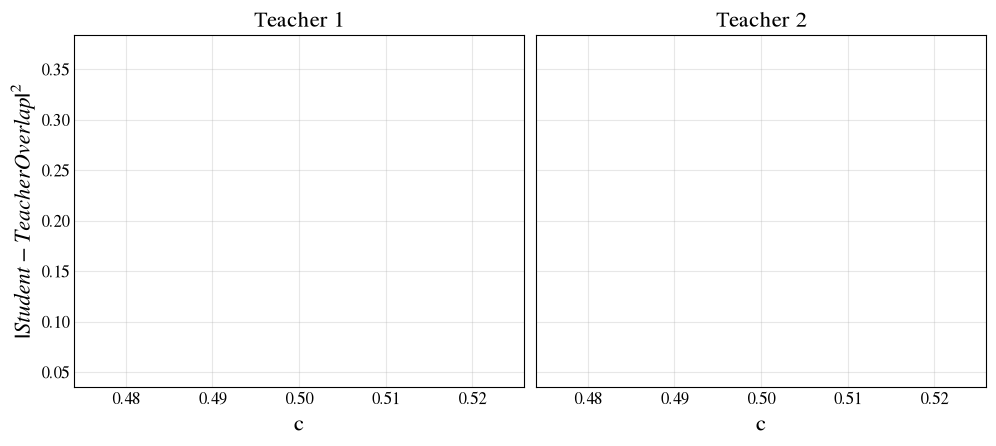

In [23]:
plot_full_overlaps_vs_rho_ODE(
    all_ode_runs=all_ode_runs,
    configs=configs,
    select_runs=select_runs,
    args=args,
)

# Plot ODEs trajectories

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import ScalarFormatter, MaxNLocator, FormatStrFormatter, AutoMinorLocator

# Mapping dictionary for clean LaTeX rendering
TITLE_MAP = {
    "h1": r"$\mathbf{h_1}$",
    "h2": r"$\mathbf{h_2}$",
    "Xi": r"$\mathbf{\Xi}$",
    "D": r"$\mathbf{D}$",
    "Phi": r"$\mathbf{\Phi}$",
    "Gamma": r"$\mathbf{\Gamma}$",
    "Lambda": r"$\mathbf{\Lambda}$",
    "Q": r"$\mathbf{Q}$",
    "R": r"$\mathbf{R}$",
    "U": r"$\mathbf{U}$"
}

# Soft pastel palette for clean, non-aggressive rendering
#PASTEL_PALETTE = [
#    "#4C72B0", "#55A868", "#C44E52", "#8172B3", "#CCB974", 
#    "#64B5CD", "#DD8452", "#DA8BC3", "#8C8C8C", "#937860"
#]


PASTEL_PALETTE = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", 
    "#937860", "#DA8BC3", "#8C8C8C", "#CCB974", "#64B5CD" #1
]

#PASTEL_PALETTE = [
#    "#3B4CC0", "#5A77E6", "#7B9FF9", "#9EBBF5", "#C2D4F0", 
#    "#F2CBB7", "#EE9B81", "#E06A54", "#C63531", "#B40426"
#]

def plot_order_parameters(
    df_ODES_run, 
    list_to_plot, 
    args, 
    df_run=None, 
    task=None, 
    absval=True, 
    log=None, 
    until_task_switch=False, 
    cols=1  # Default to vertical single-column stack
):
    active_ops = [
        op for op, plot in list_to_plot.items()
        if plot and op in df_ODES_run and op in df_ODES_run["steps"]
    ]
    num_plots = len(active_ops)
    if num_plots == 0: 
        return

    # --- Plotting Parameters ---
    axis_label_size = 18
    tick_label_size = configs["global"]["tick_label_size"]
    alpha_sim = configs["global"]["alpha_sim"]
    alpha_ODEs = configs["global"]["alpha_ODEs"]
    markevery_sim = configs["global"]["markevery_sim"]
    #markevery_sim = 1
    lw_ODEs = 1.2
    lw_task_switch = 1.8
    
    x_formatter = ScalarFormatter(useMathText=True)
    x_formatter.set_scientific(True)
    x_formatter.set_powerlimits((5, 5))

    base_palette = PASTEL_PALETTE

    # --- Modular Dimensions for Vertical Layout ---
    rows = int(np.ceil(num_plots / cols))
    plot_width = 4.5 if cols == 1 else 3.8
    panel_height = 2.2 if until_task_switch else 2.5
    fig_height = rows * panel_height

    # Using layout="constrained" handles spacing automatically & accurately
    fig, axes = plt.subplots(
        rows, cols, 
        figsize=(cols * plot_width, fig_height), 
        squeeze=False, 
        sharex=True if cols == 1 else False,  # Share X axis for vertical stacks
        sharey=False,                         # Different OPs have different Y scales
        layout="constrained"
    )
    axes_flat = axes.flatten()

    P = args.alpha * args.N if args.dataset == "synthetic" else 100000

    # Determine global X limits across all active OPs
    global_xmin, global_xmax = 0, 0
    for op in active_ops:
        ode_steps = np.array(df_ODES_run["steps"][op]) * args.integration_step * args.N
        global_xmin = min(global_xmin, np.min(ode_steps))
        if until_task_switch:
            global_xmax = max(global_xmax, P)
        else:
            global_xmax = max(global_xmax, np.max(ode_steps))

    # --- Plotting Loop ---
    for idx, op in enumerate(active_ops):
        ax = axes_flat[idx]
        base_color = base_palette[idx % len(base_palette)]
        is_bottom = (idx + cols >= num_plots)
        
        # Axis Tick Styling
        ax.tick_params(axis='both', which='both', length=0)
        ax.xaxis.set_major_formatter(x_formatter)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=3, prune='upper'))
        ax.tick_params(axis='both', labelsize=tick_label_size)
        ax.tick_params(axis='x', which='both', bottom=True, direction='out', length=4, width=1.0, labelbottom=is_bottom)
        ax.yaxis.set_major_locator(MaxNLocator(nbins=3, prune='both'))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
        ax.tick_params(axis='y', which='both', left=True, direction='out', length=4, width=1.0)
        
        offset_text = ax.xaxis.get_offset_text()
        offset_text.set_fontsize(tick_label_size)

        # Prepare ODE Data
        ode_steps = np.array(df_ODES_run["steps"][op]) * args.integration_step * args.N
        ode_vals = np.asarray(df_ODES_run[op])
        
        if until_task_switch:
            mask_o = ode_steps <= P
        else:
            mask_o = (ode_steps <= P) if task == 1 else (ode_steps >= P if task == 2 else np.ones_like(ode_steps, bool))

        # Prepare Simulation Data
        sim_data = None
        if df_run is not None:
            sim_steps = np.array(df_run["steps"][op])
            sim_vals = np.asarray(df_run[op])
            if until_task_switch:
                mask_s = sim_steps <= P
            else:
                mask_s = (sim_steps <= P) if task == 1 else (sim_steps >= P if task == 2 else np.ones_like(sim_steps, bool))
            sim_data = (sim_steps[mask_s], sim_vals[mask_s])

        _plot_single_op(
            args, ax, sim_data, (ode_steps[mask_o], ode_vals[mask_o]), 
            op, P, absval, log, markevery_sim, base_color, 
            axis_label_size, alpha_ODEs, alpha_sim, lw_ODEs, lw_task_switch
        )

    # Hide unused axes
    for i in range(num_plots, len(axes_flat)): 
        axes_flat[i].set_visible(False)
    
    # Spine and Grid Styling
    for idx, ax in enumerate(axes_flat[:num_plots]):
        is_bottom = (idx + cols >= num_plots)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        if is_bottom:
            ax.set_xlabel(r"$t$", fontsize=20)
        else:
            ax.set_xlabel("")
            
        ax.set_xlim(global_xmin, global_xmax)
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(axis='both', which='minor', length=0)
        ax.grid(True, which='major', axis='both', linestyle='-', color="#C5BFBF", linewidth=0.8, alpha=0.8, zorder=0)
        ax.grid(True, which='minor', axis='both', linestyle='-', color="#E0E0E0", linewidth=0.8, alpha=0.6, zorder=0)

    plt.savefig("for_paper/order_parameters.pdf", bbox_inches='tight', pad_inches=0.04)
    plt.show()


def _plot_single_op(args, ax, sim_data, ode_data, name, P, absval, log, markevery_sim, 
                    base_color, axis_label_size, alpha_ODEs, alpha_sim, lw_ODEs, 
                    lw_task_switch=1.0, markersize=3, method="standard"):
    o_steps, o_vals = ode_data
    first = o_vals[0]
    
    # --- Build Colormap from base_color ---
    # Using a soft neutral tint to base_color keeps row 0 visible while showing a nice gradient
    cmap = mcolors.LinearSegmentedColormap.from_list("grad", ["#C0C0C0", base_color])

    # --- Scalar Case ---
    if np.isscalar(first):
        v_ode = np.abs(o_vals) if absval else o_vals
        ax.plot(o_steps, np.log10(v_ode) if log else v_ode, 
                linestyle='-', color=base_color, lw=lw_ODEs, alpha=alpha_ODEs, zorder=3)
        
        if sim_data:
            s_steps, s_vals = sim_data
            v_sim = np.abs(s_vals) if absval else s_vals
            ax.plot(s_steps, np.log10(v_sim) if log else v_sim, 
                    linestyle='None', marker=configs[method]["marker"], 
                    markersize=markersize, 
                    color=base_color, markerfacecolor='white', markevery=markevery_sim,
                    markeredgewidth=1.2, alpha=alpha_sim, zorder=4)

    # --- Vector / Matrix Case ---
    else:
        shape = np.array(first).shape
        if len(shape) in [1, 2]:
            num_rows = shape[0]
            
            # Generate 1 color per row using cmap
            if num_rows > 1:
                row_colors = [cmap(val) for val in np.linspace(0.3, 1.0, num_rows)]
            else:
                row_colors = [base_color]

            if name == "Q":
                indices = [(i, i) for i in range(min(shape[0], shape[1]))]
            else:
                indices = [(i,) if len(shape) == 1 else (i, j) 
                           for i in range(shape[0]) 
                           for j in range(shape[1] if len(shape) == 2 else 1)]
            
            for dims in indices:
                row_idx = dims[0]
                # Every element (row_idx, j) shares the exact same row color
                line_color = row_colors[row_idx]
                
                # ODE (Theory)
                v_ode = np.array([x[dims] for x in o_vals], dtype=np.float64)
                if absval: v_ode = np.abs(v_ode)
                ax.plot(o_steps, np.log10(v_ode) if log else v_ode, 
                        linestyle='-', color=line_color, lw=lw_ODEs, alpha=alpha_ODEs, zorder=3)
                
                # Simulation dots
                if sim_data:
                    s_steps, s_vals = sim_data
                    v_sim = np.array([x[dims] for x in s_vals], dtype=np.float64)
                    if absval: v_sim = np.abs(v_sim)
                    ax.plot(s_steps, np.log10(v_sim) if log else v_sim, 
                            linestyle='None', marker=configs[method]["marker"], 
                            markersize=markersize, 
                            color=line_color, markerfacecolor='white', markevery=markevery_sim,
                            markeredgewidth=1.2, alpha=alpha_sim, zorder=4)

    formatted_title = TITLE_MAP.get(name, name)
    ax.axvline(x=P, color="grey", lw=lw_task_switch, zorder=1)
    
    if log:
        formatted_title = rf"$\log$ {formatted_title}"
    ax.set_ylabel(formatted_title, fontsize=axis_label_size)

In [25]:
def get_list_to_plot(args):
    if args.method == "standard":
        return {
            "Q": True,
            "R": True,
            "U": True,
            "h1": True,
            "h2": False,
            "Xi": False,
            "B": False,
            "Phi": False,
            "Gamma": False,
            "Lambda": False,
        }

    else:
        return {
            "Q": True,
            "R": True,
            "U": True,
            "h1": True,
            "h2": True,
            "Xi": True,
            "B": True,
            "Phi": True,
            "Gamma": True,
            "Lambda": True,
        }

args.L=10
args.rho=0.5
args.method = "Sco-standard"
list_to_plot = get_list_to_plot(args)

# Load respective runs
df_run = runs_to_dict(path_to_sim, args)
df_ODES_run = runs_to_dict(path_to_sim_ODEs, args)

# Plot order parameters for this scoring mechanism
plot_order_parameters(df_ODES_run, list_to_plot, args, df_run, absval=False, until_task_switch=True, cols = 2)

No matching configurations found in run_K=10_M=5.npy!
No matching configurations found in ODES_K=10_M=5.npy!


TypeError: argument of type 'NoneType' is not iterable

# Plot overlaps between full hidden layer and both teachers

In [26]:
def plot_methods_comparison(
    methods,
    dict_ODES,
    dict_sim,
    args,
    absval=True,
    log=None,
    tasks=[1, 2],
    after_task_switch=False,
    orientation="rows"
):
    """
    Plots a grid comparing methods across specified tasks.
    """

    task_indices = [t - 1 for t in tasks]

    # Determine grid dimensions and plot dimensions
    is_vertical = orientation in ["rows", "vertical"]

    ratio = 1.5

    if is_vertical:
        rows = len(methods)
        cols = len(task_indices)
        plot_width = 4.5 if cols > 1 else 3.5
        fig_height = rows * 2.8 / ratio
    else:
        rows = len(task_indices)
        cols = len(methods)
        plot_width = 3.8
        fig_height = 3.6

    tick_label_size = configs["global"]["tick_label_size"]
    alpha_sim = configs["global"]["alpha_sim"]
    alpha_ODEs = configs["global"]["alpha_ODEs"]
    markevery_sim = configs["global"]["markevery_sim"]

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * plot_width, fig_height),
        squeeze=False,
        sharey="row" if is_vertical else "col"
    )

    formatter = FixedExponentFormatter(exponent=6, useMathText=True)

    P = args.alpha * args.N

    for m_idx, method in enumerate(methods):

        df_odes = dict_ODES[method]
        df_sim = dict_sim.get(method) if dict_sim else None

        # ------------------------------------------------------------
        # Method-specific colors
        # ------------------------------------------------------------
        method_colors = configs[method]["colors"]

        # ------------------------------------------------------------
        # Layout depending on the method
        # ------------------------------------------------------------
        if "standard" in method.lower() and "sco-standard" not in method.lower():

            full_layout = {
                0: [{"type": "standard_full", "op": "R"}],
                1: [{"type": "standard_full", "op": "U"}]
            }

        else:

            full_layout = {
                0: [
                    {
                        "type": "standard_phase1",
                        "op": "R"
                    },
                    {
                        "type": "composite",
                        "base_op": "R",
                        "second_op": "Lambda",
                        "name": r"$\mathbf{R}(P) + \frac{\gamma}{\sqrt{L}} \mathbf{B} \mathbf{\Lambda}$"
                    }
                ],
                1: [
                    {
                        "type": "standard_phase1",
                        "op": "U"
                    },
                    {
                        "type": "composite",
                        "base_op": "U",
                        "second_op": "Gamma",
                        "name": r"$\mathbf{U}(P) + \frac{\gamma}{\sqrt{L}} \mathbf{B} \mathbf{\Gamma}$"
                    }
                ]
            }

        # ------------------------------------------------------------
        # Loop over tasks
        # ------------------------------------------------------------
        for t_idx, task_id in enumerate(task_indices):

            if is_vertical:
                row_idx, col_idx = m_idx, t_idx
            else:
                row_idx, col_idx = t_idx, m_idx

            ax = axes[row_idx, col_idx]

            is_bottom = row_idx == rows - 1
            is_left = col_idx == 0

            # --------------------------------------------------------
            # Ticks
            # --------------------------------------------------------
            ax.tick_params(
                axis="both",
                which="both",
                length=0
            )

            # X-axis
            ax.xaxis.set_major_formatter(formatter)
            ax.xaxis.set_major_locator(
                MaxNLocator(nbins=5, prune="both")
            )

            ax.tick_params(
                axis="x",
                which="both",
                bottom=True,
                direction="out",
                length=4,
                width=1.0,
                labelbottom=is_bottom,
                labelsize=20
            )

            # Y-axis
            show_y_ticks = is_left if is_vertical else True

            ax.yaxis.set_major_locator(
                MaxNLocator(nbins=4, prune="both")
            )

            ax.yaxis.set_major_formatter(
                FormatStrFormatter("%.1f")
            )

            ax.tick_params(
                axis="y",
                which="both",
                left=show_y_ticks,
                labelleft=show_y_ticks,
                right=False,
                labelright=False,
                direction="out",
                length=4,
                width=1.0,
                labelsize=20
            )

            # Minor ticks
            ax.xaxis.set_minor_locator(
                AutoMinorLocator(2)
            )
            ax.yaxis.set_minor_locator(
                AutoMinorLocator(2)
            )

            ax.tick_params(
                axis="both",
                which="minor",
                length=0
            )

            # --------------------------------------------------------
            # Get task layout and method-specific color
            # --------------------------------------------------------
            phases = full_layout[task_id]

            # task_id = 0 -> first color
            # task_id = 1 -> second color
            base_color = method_colors[0]

            # --------------------------------------------------------
            # Plot phases
            # --------------------------------------------------------
            for phase_info in phases:

                ptype = phase_info["type"]

                # ====================================================
                # 1. Full trajectory
                # ====================================================
                if ptype == "standard_full":

                    op = phase_info["op"]

                    o_steps = (
                        np.array(df_odes["steps"][op])
                        * args.integration_step
                        * args.N
                    )

                    o_vals = np.asarray(df_odes[op])

                    if after_task_switch:

                        mask_o = o_steps >= P

                        o_steps = o_steps[mask_o]
                        o_vals = o_vals[mask_o]

                    sim_data = None

                    if df_sim is not None:

                        s_steps = np.array(
                            df_sim["steps"][op]
                        )

                        s_vals = np.asarray(
                            df_sim[op]
                        )

                        if after_task_switch:

                            mask_s = s_steps >= P

                            s_steps = s_steps[mask_s]
                            s_vals = s_vals[mask_s]

                        sim_data = (s_steps, s_vals)

                # ====================================================
                # 2. Phase 1 only
                # ====================================================
                elif ptype == "standard_phase1":

                    if after_task_switch:
                        continue

                    op = phase_info["op"]

                    ode_steps = (
                        np.array(df_odes["steps"][op])
                        * args.integration_step
                        * args.N
                    )

                    ode_vals = np.asarray(
                        df_odes[op]
                    )

                    mask_o = ode_steps <= P

                    o_steps = ode_steps[mask_o]
                    o_vals = ode_vals[mask_o]

                    sim_data = None

                    if df_sim is not None:

                        sim_steps = np.array(
                            df_sim["steps"][op]
                        )

                        sim_vals = np.asarray(
                            df_sim[op]
                        )

                        mask_s = sim_steps <= P

                        sim_data = (
                            sim_steps[mask_s],
                            sim_vals[mask_s]
                        )

                # ====================================================
                # 3. Composite phase after P
                # ====================================================
                elif ptype == "composite":

                    base_op = phase_info["base_op"]
                    second_op = phase_info["second_op"]

                    coeff = args.gamma / np.sqrt(args.L)

                    # ------------------------------------------------
                    # ODE
                    # ------------------------------------------------
                    step_base_ode = (
                        np.array(df_odes["steps"][base_op])
                        * args.integration_step
                        * args.N
                    )

                    idx_P_ode = np.argmin(
                        np.abs(step_base_ode - P)
                    )

                    base_P_ode = np.asarray(
                        df_odes[base_op]
                    )[idx_P_ode]

                    step_B_ode = (
                        np.array(df_odes["steps"]["B"])
                        * args.integration_step
                        * args.N
                    )

                    mask_o = step_B_ode >= P

                    o_steps = step_B_ode[mask_o]

                    B_ode = np.asarray(
                        df_odes["B"]
                    )[mask_o]

                    second_ode = np.asarray(
                        df_odes[second_op]
                    )[mask_o]

                    if (
                        B_ode.ndim == 3
                        and second_ode.ndim == 3
                    ):

                        dot_ode = np.squeeze(
                            B_ode
                            @ second_ode.transpose(0, 2, 1)
                        )

                    else:

                        dot_ode = np.sum(
                            B_ode * second_ode,
                            axis=-1
                        )

                    o_vals = (
                        base_P_ode
                        + coeff * dot_ode
                    )

                    # ------------------------------------------------
                    # Simulation
                    # ------------------------------------------------
                    sim_data = None

                    if df_sim is not None:

                        step_base_sim = np.array(
                            df_sim["steps"][base_op]
                        )

                        idx_P_sim = np.argmin(
                            np.abs(step_base_sim - P)
                        )

                        base_P_sim = np.asarray(
                            df_sim[base_op]
                        )[idx_P_sim]

                        step_B_sim = np.array(
                            df_sim["steps"]["B"]
                        )

                        mask_s = step_B_sim >= P

                        s_steps = step_B_sim[mask_s]

                        B_sim = np.asarray(
                            df_sim["B"]
                        )[mask_s]

                        second_sim = np.asarray(
                            df_sim[second_op]
                        )[mask_s]

                        if (
                            B_sim.ndim == 3
                            and second_sim.ndim == 3
                        ):

                            dot_sim = np.squeeze(
                                B_sim
                                @ second_sim.transpose(0, 2, 1)
                            )

                        else:

                            dot_sim = np.sum(
                                B_sim * second_sim,
                                axis=-1
                            )

                        s_vals = (
                            base_P_sim
                            + coeff * dot_sim
                        )

                        sim_data = (
                            s_steps,
                            s_vals
                        )

                # ----------------------------------------------------
                # Plot
                # ----------------------------------------------------
                _plot_single_op(
                    args=args,
                    ax=ax,
                    sim_data=sim_data,
                    ode_data=(o_steps, o_vals),
                    name="",
                    P=P,
                    absval=absval,
                    log=log,
                    markevery_sim=markevery_sim,
                    base_color=base_color,
                    axis_label_size=20,
                    alpha_ODEs=alpha_ODEs,
                    alpha_sim=alpha_sim,
                    lw_ODEs=1,
                    lw_task_switch=1.0
                )

            # --------------------------------------------------------
            # Labels
            # --------------------------------------------------------
            ax.set_title("")

            if is_vertical:

                if is_left:
                    ax.set_ylabel(
                        f"{method}",
                        fontsize=20,
                        fontweight="bold"
                    )
                else:
                    ax.set_ylabel("")

            else:

                ax.set_ylabel(
                    f"{method}",
                    fontsize=20,
                    fontweight="bold"
                )

            if is_bottom:

                ax.set_xlabel(
                    r"$t$",
                    fontsize=20
                )

            else:

                ax.set_xlabel("")

            # --------------------------------------------------------
            # Spines and limits
            # --------------------------------------------------------
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            ax.spines["left"].set_linewidth(0.8)
            ax.spines["bottom"].set_linewidth(0.8)

            start_x = P if after_task_switch else 0

            ax.set_xlim(left=start_x)

            # Do not manually set the y-ticks:
            # MaxNLocator above controls them.
            # ax.set_yticks(np.linspace(0, 0.4, num=3))

            # --------------------------------------------------------
            # Grid
            # --------------------------------------------------------
            ax.grid(
                True,
                which="major",
                axis="both",
                linestyle="-",
                color="#C5BFBF",
                linewidth=0.8,
                alpha=0.8,
                zorder=0
            )

            ax.grid(
                True,
                which="minor",
                axis="both",
                linestyle="-",
                color="#E0E0E0",
                linewidth=0.8,
                alpha=0.6,
                zorder=0
            )

            offset_text = ax.xaxis.get_offset_text()
            offset_text.set_fontsize(20)

    fig.subplots_adjust(
        wspace=0.35,
        hspace=0.35
    )

    plt.tight_layout()

    plt.savefig(
        "results/overlap_comparison.pdf",
        bbox_inches="tight",
        pad_inches=0.06
    )

    plt.show()

No matching configurations found in run_K=10_M=5.npy!
No matching configurations found in ODES_K=10_M=5.npy!
No matching configurations found in run_K=10_M=5.npy!
No matching configurations found in ODES_K=10_M=5.npy!


TypeError: 'NoneType' object is not subscriptable

/tmp/ipykernel_3820598/2297766125.py:117: MatplotlibDeprecationWarning: The orderOfMagnitude attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.orderOfMagnitude = self.exponent


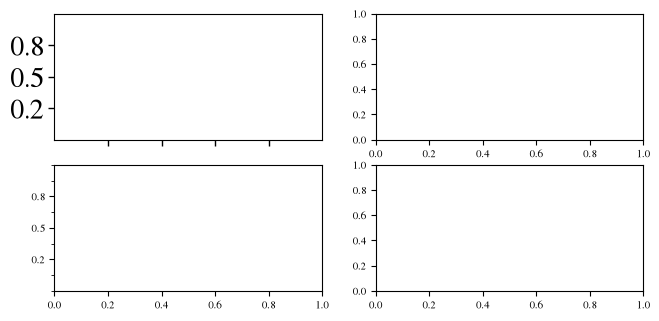

In [27]:
dict_ODES = {}
dict_sim = {}

args.rho = 0.5

comparison_configs = [
    # {"method": "standard", "scoring_method": "SDGM"},
    # {"method": "LoRA", "scoring_method": "SDGM"},
    {"method": "Sco-LoRA", "scoring_method": "SDGM"},
    {"method": "Sco-standard", "scoring_method": "SDGM"},
]

methods_to_compare = []

for cfg in comparison_configs:
    args.method = cfg["method"]
    args.scoring_method = cfg["scoring_method"]

    key_name = cfg["method"]
    methods_to_compare.append(key_name)

    dict_sim[key_name] = runs_to_dict(path_to_sim, args)
    dict_ODES[key_name] = runs_to_dict(path_to_sim_ODEs, args)
    
plot_methods_comparison(methods_to_compare, dict_ODES, dict_sim, args, tasks=[1,2], after_task_switch=True, orientation="horizontal")

TypeError: 'NoneType' object is not subscriptable

/tmp/ipykernel_3820598/2297766125.py:117: MatplotlibDeprecationWarning: The orderOfMagnitude attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.orderOfMagnitude = self.exponent


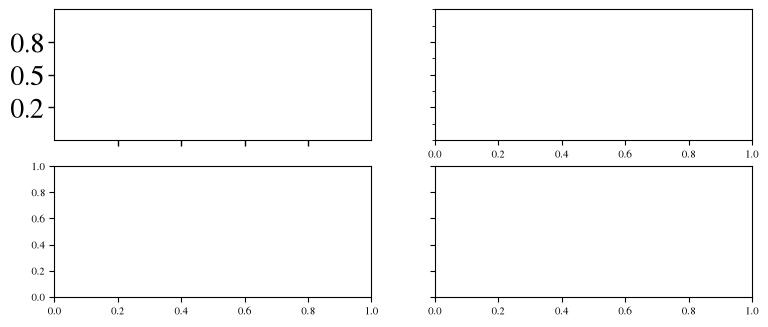

In [28]:
plot_methods_comparison(methods_to_compare, dict_ODES, dict_sim, args, tasks=[1,2], after_task_switch=True, orientation="vertical")

# Fig 1

In [43]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.ticker import ScalarFormatter, MaxNLocator, AutoMinorLocator, FormatStrFormatter
import matplotlib.lines as mlines
from matplotlib import cm

# ==========================================
# 1. Publication Style Settings (ICLR)
# ==========================================
FONT_LABEL = 8.0
FONT_TICK = 6.5

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 7.0,
    "axes.labelsize": FONT_LABEL,
    "axes.titlesize": 7.5,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "lines.linewidth": 1.0,
    "lines.markersize": 3.0,
})


# ==========================================
# 2. Modular Plotting Helpers (Axis-based)
# ==========================================

def draw_plot_a(ax, all_sim_runs, all_ode_runs, args, configs, methods_to_plot):
    """Populates Plot (a): Generalization Error on a single axis."""
    lw_task1 = 1.2
    lw_task2 = 1.2
    markevery_sim = configs["global"]["markevery_sim"]

    target_configs = {k: v for k, v in configs.items() if k in methods_to_plot}

    for label, cfg in target_configs.items():
        sim_run = select_single_trajectory_run(all_sim_runs, args, label)
        ode_run = select_single_trajectory_run(all_ode_runs, args, label)

        if ode_run is not None and "logs" in ode_run:
            ode_logs = ode_run["logs"]
            if "test_loss_1" in ode_logs and "test_loss_2" in ode_logs:
                loss_ref_1 = np.asarray(ode_logs["test_loss_1"]["values"], dtype=np.float64)
                loss_ref_2 = np.asarray(ode_logs["test_loss_2"]["values"], dtype=np.float64)
                t_span = np.arange(len(loss_ref_1)) * args.integration_step * args.N

                ax.plot(t_span, np.log10(loss_ref_1), color=cfg["colors"][0], linestyle='-', lw=lw_task1, alpha=0.8, zorder=3)
                ax.plot(t_span, np.log10(loss_ref_2), color=cfg["colors"][1], linestyle='-', lw=lw_task2, alpha=0.8, zorder=1)

        if sim_run is not None and "logs" in sim_run:
            sim_logs = sim_run["logs"]
            if "test_loss_1" in sim_logs and "test_loss_2" in sim_logs:
                steps = np.array(sim_logs["test_loss_1"]["steps"])
                ax.plot(steps, np.log10(np.asarray(sim_logs["test_loss_1"]["values"], dtype=np.float64)),
                        linestyle='None', marker=cfg["marker"], markevery=markevery_sim,
                        color=cfg["colors"][0], markerfacecolor='white', markersize=(2.5 if label != "standard" else 3.75), markeredgewidth=0.8, alpha=1.0, zorder=4)
                ax.plot(steps, np.log10(np.asarray(sim_logs["test_loss_2"]["values"], dtype=np.float64)),
                        linestyle='None', marker=cfg["marker"], markevery=markevery_sim,
                        color=cfg["colors"][1], markerfacecolor='white', markersize=(2.5 if label != "standard" else 3.75), markeredgewidth=0.8, alpha=1.0, zorder=2)

    P_time = args.N * args.alpha
    ax.axvline(x=P_time, color="grey", lw=0.8, linestyle="--", zorder=0)


    formatter = FixedExponentFormatter(exponent=5, useMathText=True)
    ax.xaxis.set_major_formatter(formatter)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6, prune='both'))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=8, prune='both'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
    ax.set_xlabel(r"$t$", fontsize=FONT_LABEL, labelpad=1)
    ax.set_ylabel(r"$\log \epsilon^*$", fontsize=FONT_LABEL, labelpad=2)
    ax.xaxis.get_offset_text().set_fontsize(FONT_TICK)

    # In-plot Legend
    legend_handles = [
        mlines.Line2D([], [], color=cfg["colors"][0], marker=cfg["marker"], linestyle='-',
                      markersize=3.0, markerfacecolor="white", markeredgewidth=0.8, label=METHOD_LABELS.get(m, m))
        for m, cfg in target_configs.items()
    ]
    leg = ax.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(0.98, 0.9), frameon=True, edgecolor='#e2e8f0', facecolor='white', fontsize=6.0)
    for text in leg.get_texts():
        text.set_fontweight('bold')


def draw_overlap_single_axis(ax, method, task_id, dict_ODES, dict_sim, args, after_task_switch=True):
    """Populates a single overlap plot for panels (d) or (e)."""
    df_odes = dict_ODES[method]
    df_sim = dict_sim.get(method) if dict_sim else None

    alpha_sim = configs["global"]["alpha_sim"]
    alpha_ODEs = configs["global"]["alpha_ODEs"]
    markevery_sim = configs["global"]["markevery_sim"]
    P = args.alpha * args.N

    if "standard" in method.lower() and "sco-standard" not in method.lower():
        full_layout = {
            0: [{"type": "standard_full", "op": "R"}],
            1: [{"type": "standard_full", "op": "U"}]
        }
    else:
        full_layout = {
            0: [
                {"type": "standard_phase1", "op": "R"},
                {"type": "composite", "base_op": "R", "second_op": "Lambda", "name": r"$\mathbf{R}(P) + \frac{\gamma}{\sqrt{L}} \mathbf{B} \mathbf{\Lambda}$"}
            ],
            1: [
                {"type": "standard_phase1", "op": "U"},
                {"type": "composite", "base_op": "U", "second_op": "Gamma", "name": r"$\mathbf{U}(P) + \frac{\gamma}{\sqrt{L}} \mathbf{B} \mathbf{\Gamma}$"}
            ]
        }

    phases = full_layout[task_id]

    for phase_info in phases:
        ptype = phase_info["type"]
        
        if ptype == "standard_full":
            op = phase_info["op"]
            o_steps = np.array(df_odes["steps"][op]) * args.integration_step * args.N
            o_vals = np.asarray(df_odes[op])
            if after_task_switch:
                mask_o = (o_steps >= P)
                o_steps, o_vals = o_steps[mask_o], o_vals[mask_o]
            
            sim_data = None
            if df_sim is not None:
                s_steps = np.array(df_sim["steps"][op])
                s_vals = np.asarray(df_sim[op])
                if after_task_switch:
                    mask_s = (s_steps >= P)
                    s_steps, s_vals = s_steps[mask_s], s_vals[mask_s]
                sim_data = (s_steps, s_vals)

        elif ptype == "standard_phase1":
            if after_task_switch:
                continue
            op = phase_info["op"]
            ode_steps = np.array(df_odes["steps"][op]) * args.integration_step * args.N
            ode_vals = np.asarray(df_odes[op])
            mask_o = (ode_steps <= P)
            o_steps, o_vals = ode_steps[mask_o], ode_vals[mask_o]

            sim_data = None
            if df_sim is not None:
                sim_steps = np.array(df_sim["steps"][op])
                sim_vals = np.asarray(df_sim[op])
                mask_s = (sim_steps <= P)
                sim_data = (sim_steps[mask_s], sim_vals[mask_s])

        elif ptype == "composite":
            base_op = phase_info["base_op"]
            second_op = phase_info["second_op"]
            coeff = args.gamma / np.sqrt(args.L)

            step_base_ode = np.array(df_odes["steps"][base_op]) * args.integration_step * args.N
            idx_P_ode = np.argmin(np.abs(step_base_ode - P))
            base_P_ode = np.asarray(df_odes[base_op])[idx_P_ode]

            step_B_ode = np.array(df_odes["steps"]["B"]) * args.integration_step * args.N
            mask_o = (step_B_ode >= P)
            o_steps = step_B_ode[mask_o]

            B_ode = np.asarray(df_odes["B"])[mask_o]
            second_ode = np.asarray(df_odes[second_op])[mask_o]

            dot_ode = np.squeeze(B_ode @ second_ode.transpose(0, 2, 1)) if (B_ode.ndim == 3 and second_ode.ndim == 3) else np.sum(B_ode * second_ode, axis=-1)
            o_vals = base_P_ode + coeff * dot_ode

            sim_data = None
            if df_sim is not None:
                step_base_sim = np.array(df_sim["steps"][base_op])
                idx_P_sim = np.argmin(np.abs(step_base_sim - P))
                base_P_sim = np.asarray(df_sim[base_op])[idx_P_sim]

                step_B_sim = np.array(df_sim["steps"]["B"])
                mask_s = (step_B_sim >= P)
                s_steps = step_B_sim[mask_s]

                B_sim = np.asarray(df_sim["B"])[mask_s]
                second_sim = np.asarray(df_sim[second_op])[mask_s]

                dot_sim = np.squeeze(B_sim @ second_sim.transpose(0, 2, 1)) if (B_sim.ndim == 3 and second_sim.ndim == 3) else np.sum(B_sim * second_sim, axis=-1)
                s_vals = base_P_sim + coeff * dot_sim
                sim_data = (s_steps, s_vals)
        base_color = configs[method]["colors"][0]
        _plot_single_op(
            args=args,
            ax=ax,
            sim_data=sim_data,
            ode_data=(o_steps, o_vals),
            name="",
            P=P,
            absval=True,
            log=None,
            markevery_sim=markevery_sim,
            base_color=base_color,
            axis_label_size=FONT_LABEL,
            alpha_ODEs=alpha_ODEs,
            alpha_sim=alpha_sim,
            lw_ODEs=0.9,
            lw_task_switch=0.8,
            markersize=(2.5 if method != "standard" else 3.75),
            method=method,
        )

    # Formatting Axis
    formatter = FixedExponentFormatter(exponent=5, useMathText=True)
    ax.xaxis.set_major_formatter(formatter)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3, prune='both'))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, prune='both'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax.set_yticks(np.linspace(0, 0.4, num=3))

    start_x = P if after_task_switch else 0
    ax.set_xlim(left=start_x)




In [44]:
# ==========================================
# 3. Main Figure Master Layout Assembly
# ==========================================

dict_ODES = {}
dict_sim = {}
args.rho=0.5
# Define what combinations you want to compare
# You can mix base methods and scored methods here
comparison_configs = [
    {"method": "standard", "scoring_method": "SDGM"},
    {"method": "LoRA", "scoring_method": "SDGM"},
    #{"method": "Sco-LoRA", "scoring_method": "SDGM"},
    #{"method": "Sco-standard", "scoring_method": "inv_SDGM"},
    #{"method": "Sco-standard", "scoring_method": "re-use"},
]

methods_to_compare = []

for cfg in comparison_configs:
    args.method = cfg["method"]
    args.scoring_method = cfg["scoring_method"]
    
    key_name = cfg["method"]
    methods_to_compare.append(key_name)
    
    dict_sim[key_name] = runs_to_dict(path_to_sim, args)
    dict_ODES[key_name] = runs_to_dict(path_to_sim_ODEs, args)

fig = plt.figure(figsize=(5.5, 3.2), layout='constrained')

# ==========================================
# Plot (a): Generalization error
# ==========================================

fig, ax_a = plt.subplots(figsize=(3.2, 2.2))
methods_a = ["standard", "LoRA"]

draw_plot_a(
    ax_a,
    all_sim_runs,
    all_ode_runs,
    args,
    configs,
    methods_to_plot=methods_a,
)

ax_a.text(0.0,1.1,"Generalization error",transform=ax_a.transAxes,fontsize=8.0,fontweight="bold",)
#ax_a.set_title("Generalization error",loc="left",fontsize=8.5,fontweight="bold",pad=3,
#)

# Styling
ax_a.spines["top"].set_visible(False)
ax_a.spines["right"].set_visible(False)
ax_a.spines["left"].set_linewidth(0.6)
ax_a.spines["left"].set_zorder(5)
ax_a.spines["bottom"].set_linewidth(0.6)

ax_a.tick_params(axis="both",which="major",labelsize=FONT_TICK,length=2.5,width=0.6,direction="out",)

ax_a.minorticks_on()
ax_a.tick_params(axis="both", which="minor", length=0)

ax_a.grid(True,which="major",linestyle="-",color="#C5BFBF",linewidth=0.5,alpha=0.7,zorder=0,)
ax_a.grid(True,which="minor",linestyle=":",color="#E0E0E0",linewidth=0.35,alpha=0.5,zorder=0)

fig.subplots_adjust(left=0.17, right=0.99, bottom=0.15, top=0.87)
fig.savefig("for_paper/generalization_error.pdf")

plt.close(fig)


# ==========================================
# Plot (b): Task 1 overlap
# ==========================================

fig, (ax_b1, ax_b2) = plt.subplots(1,2,figsize=(2.70, 1.05),sharey=True,gridspec_kw={"wspace": 0.10},)

draw_overlap_single_axis(ax_b1,method="standard",task_id=0,dict_ODES=dict_ODES,dict_sim=dict_sim,args=args,after_task_switch=True,)
draw_overlap_single_axis(ax_b2,method="LoRA",task_id=0,dict_ODES=dict_ODES,dict_sim=dict_sim,args=args,after_task_switch=True,)

# Titles inside the pair
#ax_b1.set_title("Standard", fontsize=7.0, pad=2)
#ax_b2.set_title("LoRA", fontsize=7.0, pad=2)

# Panel title
ax_b1.text(0.0,1.28,"Task 1 overlap",transform=ax_b1.transAxes,fontsize=8.0,fontweight="bold",)

# Styling
for ax in [ax_b1, ax_b2]:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["left"].set_zorder(5)
    ax.spines["bottom"].set_linewidth(0.6)

    ax.tick_params(axis="both",which="major",labelsize=FONT_TICK,length=2.5,width=0.6,direction="out",)
    ax.minorticks_on()
    ax.tick_params(axis="both", which="minor", length=0)
    ax.grid(True,which="major",linestyle="-",color="#C5BFBF",linewidth=0.5,alpha=0.7,zorder=0,)
    ax.grid(True,which="minor",linestyle=":",color="#E0E0E0",linewidth=0.35,alpha=0.5,zorder=0,)
    ax.set_xlabel(r"$t$", fontsize=FONT_LABEL, labelpad=1)
    ax.xaxis.get_offset_text().set_fontsize(FONT_TICK)
    
plt.setp(ax_b2.get_yticklabels(), visible=False)
fig.subplots_adjust(left=0.16,right=0.99,bottom=0.32,top=0.76,)
fig.savefig("for_paper/task1_overlap.pdf",format="pdf",)
plt.close(fig)

# ==========================================
# Plot (c): Task 2 overlap
# ==========================================

fig, (ax_c1, ax_c2) = plt.subplots(1,2,figsize=(2.70, 1.05),sharey=True,gridspec_kw={"wspace": 0.10},)

draw_overlap_single_axis(ax_c1,method="standard",task_id=1,dict_ODES=dict_ODES,dict_sim=dict_sim,args=args,after_task_switch=True,)

draw_overlap_single_axis(ax_c2,method="LoRA",task_id=1,dict_ODES=dict_ODES,dict_sim=dict_sim,args=args,after_task_switch=True,)

#ax_c1.set_title("Standard", fontsize=7.0, pad=2)
#ax_c2.set_title("LoRA", fontsize=7.0, pad=2)
ax_c1.text(0.0,1.28,"Task 2 overlap",transform=ax_c1.transAxes,fontsize=8.0,fontweight="bold",)

for ax in [ax_c1, ax_c2]:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["left"].set_zorder(5)
    ax.spines["bottom"].set_linewidth(0.6)
    ax.tick_params(axis="both",which="major",labelsize=FONT_TICK,length=2.5,width=0.6,direction="out",)

    ax.minorticks_on()
    ax.tick_params(axis="both", which="minor", length=0)
    ax.grid(True,which="major",linestyle="-",color="#C5BFBF",linewidth=0.5,alpha=0.7,zorder=0,)
    ax.grid(True,which="minor",linestyle=":",color="#E0E0E0",linewidth=0.35,alpha=0.5,zorder=0,)

    ax.set_xlabel(r"$t$", fontsize=FONT_LABEL, labelpad=1)
    ax.xaxis.get_offset_text().set_fontsize(FONT_TICK)

plt.setp(ax_c2.get_yticklabels(), visible=False)
fig.subplots_adjust(left=0.16,right=0.99,bottom=0.32,top=0.76,)
fig.savefig("for_paper/task2_overlap.pdf",format="pdf",)

plt.close(fig)

/tmp/ipykernel_3820598/2297766125.py:117: MatplotlibDeprecationWarning: The orderOfMagnitude attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.orderOfMagnitude = self.exponent


<Figure size 550x320 with 0 Axes>

In [66]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator


def _get_matrix_diag(arr):
    """Extracts diagonal elements if input is a 2D/3D matrix batch."""
    arr = np.asarray(arr)
    if arr.ndim >= 2 and arr.shape[-1] == arr.shape[-2]:
        return np.diagonal(arr, axis1=-2, axis2=-1)
    return arr


def _compute_norm_diag(Q, Xi, B, Phi, gamma):
    """
    Computes the diagonal of: Q + gamma * Xi * B^T + gamma * B * Xi^T + gamma^2 * B * Phi * B^T
    Handles 3D tensor batches (T, K, K) or pre-vectorized 2D arrays (T, K).
    """
    if Q.ndim == 3:  # (T, K, K) batch matrices
        Xi_BT = Xi @ B.transpose(0, 2, 1)
        B_XiT = B @ Xi.transpose(0, 2, 1)

        if Phi.ndim == 3:  # (T, r, r)
            B_Phi_BT = (B @ Phi) @ B.transpose(0, 2, 1)
        elif Phi.ndim == 2:  # (T, r)
            B_Phi_BT = (B * Phi[:, None, :]) @ B.transpose(0, 2, 1)
        else:
            B_Phi_BT = (B * Phi) @ B.transpose(0, 2, 1)

        M = Q + gamma * Xi_BT + gamma * B_XiT + (gamma ** 2) * B_Phi_BT
        return np.diagonal(M, axis1=1, axis2=2)

    elif Q.ndim == 2 and Q.shape[0] == Q.shape[1]:  # Single step (K, K)
        M = Q + gamma * (Xi @ B.T) + gamma * (B @ Xi.T) + (gamma ** 2) * ((B @ Phi) @ B.T)
        return np.diagonal(M)

    else:  # Fallback for 2D vectorized (T, K) inputs
        Xi_BT = np.sum(Xi * B, axis=-1)
        B_XiT = np.sum(B * Xi, axis=-1)
        B_Phi_BT = np.sum(B * (Phi * B), axis=-1) if Phi.ndim >= 2 else np.sum(B * Phi * B, axis=-1)
        return Q + gamma * Xi_BT + gamma * B_XiT + (gamma ** 2) * B_Phi_BT


def plot_methods_norm_comparison(methods, dict_ODES, dict_sim, args, absval=True, log=None):
    """
    Plots a single-column grid comparing the layer norm across methods for full training.
    - Standard methods: Plot diagonal of Q across full training.
    - LoRA methods: Phase 1 (<= P) plots diagonal of Q; Phase 2 (>= P) plots diagonal of 
      Q + gamma * Xi * B^T + gamma * B * Xi^T + gamma^2 * B * Phi * B^T.
    """
    cols = 1
    rows = len(methods)
    plot_size = 4
    fig, axes = plt.subplots(rows, cols, figsize=(cols * plot_size, rows * plot_size), squeeze=False, sharey="row")

    formatter = FixedExponentFormatter(exponent=5, useMathText=True)
    base_palette = cm.tab10(np.linspace(0, 1, 2))
    P = args.alpha * args.N

    column_titles = ["Norm"]

    for row_idx, method in enumerate(methods):
        df_odes = dict_ODES[method]
        df_sim = dict_sim.get(method) if dict_sim else None

        # Standard vs. LoRA method layout
        if "standard" in method.lower() and "sco-standard" not in method.lower():
            task_layout = [
                {"type": "standard_full", "op": "Q"}
            ]
        else:
            task_layout = [
                {"type": "standard_phase1", "op": "Q"},
                {
                    "type": "norm_composite",
                    "name": r"$\mathbf{Q} + \gamma \mathbf{\Xi}\mathbf{B}^T + \gamma \mathbf{B}\mathbf{\Xi}^T + \gamma^2 \mathbf{B}\mathbf{\Phi}\mathbf{B}^T$"
                }
            ]

        ax = axes[row_idx, 0]
        ax.tick_params(axis="y", which="both", left=True, labelleft=True, right=False, labelright=False)
        base_color = base_palette[0]

        ax.xaxis.set_major_formatter(formatter)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, prune='both'))

        for phase_info in task_layout:
            ptype = phase_info["type"]

            # 1. Standard Full Trajectory
            if ptype == "standard_full":
                op = phase_info["op"]
                o_steps = np.array(df_odes["steps"][op]) * args.integration_step * args.N
                o_vals = _get_matrix_diag(df_odes[op])

                sim_data = None
                if df_sim is not None:
                    s_steps = np.array(df_sim["steps"][op])
                    s_vals = _get_matrix_diag(df_sim[op])
                    sim_data = (s_steps, s_vals)

                plot_name = op

            # 2. Phase 1 Only (Up to P)
            elif ptype == "standard_phase1":
                op = phase_info["op"]
                ode_steps = np.array(df_odes["steps"][op]) * args.integration_step * args.N
                mask_o = (ode_steps <= P)

                o_steps = ode_steps[mask_o]
                o_vals = _get_matrix_diag(df_odes[op])[mask_o]

                sim_data = None
                if df_sim is not None:
                    sim_steps = np.array(df_sim["steps"][op])
                    mask_s = (sim_steps <= P)
                    s_steps = sim_steps[mask_s]
                    s_vals = _get_matrix_diag(df_sim[op])[mask_s]
                    sim_data = (s_steps, s_vals)

                plot_name = op

            # 3. LoRA Composite Phase 2 Norm (After P)
            elif ptype == "norm_composite":
                # Filter each parameter independently by its own step tracking to prevent index size mismatches
                step_Q_ode = np.array(df_odes["steps"]["Q"]) * args.integration_step * args.N
                mask_Q_ode = (step_Q_ode >= P)
                Q_ode = np.asarray(df_odes["Q"])[mask_Q_ode]

                step_B_ode = np.array(df_odes["steps"]["B"]) * args.integration_step * args.N
                mask_B_ode = (step_B_ode >= P)
                o_steps = step_B_ode[mask_B_ode]
                B_ode = np.asarray(df_odes["B"])[mask_B_ode]

                step_Xi_ode = np.array(df_odes["steps"].get("Xi", df_odes["steps"]["B"])) * args.integration_step * args.N
                Xi_ode = np.asarray(df_odes["Xi"])[step_Xi_ode >= P]

                step_Phi_ode = np.array(df_odes["steps"].get("Phi", df_odes["steps"]["B"])) * args.integration_step * args.N
                Phi_ode = np.asarray(df_odes["Phi"])[step_Phi_ode >= P]

                o_vals = _compute_norm_diag(Q_ode, Xi_ode, B_ode, Phi_ode, args.gamma)

                sim_data = None
                if df_sim is not None:
                    step_Q_sim = np.array(df_sim["steps"]["Q"])
                    Q_sim = np.asarray(df_sim["Q"])[step_Q_sim >= P]

                    step_B_sim = np.array(df_sim["steps"]["B"])
                    mask_B_sim = (step_B_sim >= P)
                    s_steps = step_B_sim[mask_B_sim]
                    B_sim = np.asarray(df_sim["B"])[mask_B_sim]

                    step_Xi_sim = np.array(df_sim["steps"].get("Xi", df_sim["steps"]["B"]))
                    Xi_sim = np.asarray(df_sim["Xi"])[step_Xi_sim >= P]

                    step_Phi_sim = np.array(df_sim["steps"].get("Phi", df_sim["steps"]["B"]))
                    Phi_sim = np.asarray(df_sim["Phi"])[step_Phi_sim >= P]

                    s_vals = _compute_norm_diag(Q_sim, Xi_sim, B_sim, Phi_sim, args.gamma)
                    sim_data = (s_steps, s_vals)

                plot_name = phase_info["name"]

            _plot_single_op(
                args=args,
                ax=ax,
                sim_data=sim_data,
                ode_data=(o_steps, o_vals),
                name=plot_name,
                P=P,
                absval=absval,
                log=log,
                markevery_sim=20,
                base_color=base_color,
                axis_label_size=12,
                alpha_ODEs=1.0,
                alpha_sim=0.8,
                lw_ODEs=1.0,
                lw_task_switch=1.0
            )

        ax.set_ylabel(f"{method}", fontsize=12, fontweight='bold')

        if row_idx == 0:
            ax.set_title(column_titles[0], fontsize=16)

        for side in ['top', 'right', 'left', 'bottom']:
            ax.spines[side].set_linewidth(0.5)
        ax.set_xlabel(r"$s$", fontsize=10)
        ax.set_box_aspect(1)
        ax.tick_params(labelsize=12)

    fig.subplots_adjust(hspace=0.3)
    plt.tight_layout()
    plt.savefig("results/methods_norm_comparison.pdf")
    plt.show()

No matching configurations found in run_K=10_M=5.npy!
No matching configurations found in run_K=10_M=5.npy!


IndexError: tuple index out of range

/tmp/ipykernel_3761621/2297766125.py:117: MatplotlibDeprecationWarning: The orderOfMagnitude attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.orderOfMagnitude = self.exponent


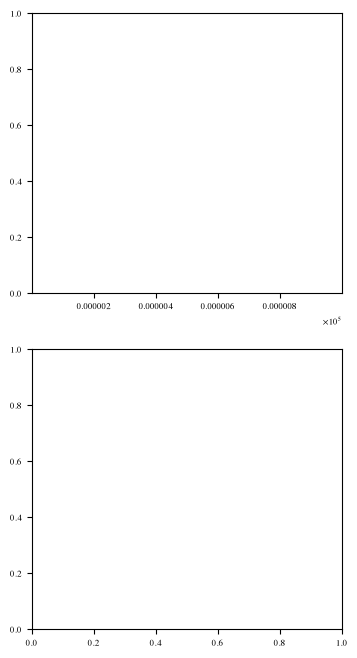

In [67]:
dict_ODES = {}
dict_sim = {}
args.rho=0.5
# Define what combinations you want to compare
# You can mix base methods and scored methods here
comparison_configs = [
    {"method": "standard", "scoring_method": "SDGM"},
    {"method": "LoRA", "scoring_method": "SDGM"},
    #{"method": "Sco-LoRA", "scoring_method": "SDGM"},
    #{"method": "Sco-standard", "scoring_method": "inv_SDGM"},
    #{"method": "Sco-standard", "scoring_method": "re-use"},
]

methods_to_compare = []

for cfg in comparison_configs:
    args.method = cfg["method"]
    args.scoring_method = cfg["scoring_method"]
    
    key_name = cfg["method"]
    methods_to_compare.append(key_name)
    
    dict_sim[key_name] = runs_to_dict(path_to_sim, args)
    dict_ODES[key_name] = runs_to_dict(path_to_sim_ODEs, args)
    

plot_methods_norm_comparison(methods_to_compare, dict_ODES, dict_sim, args,)

In [ ]:
import numpy as np
import os

def delete_runs_with_args(path, args):
    """
    Deletes runs from the .npy file that match the provided args.
    """
    def match_predicate(meta):
        return (
            int(meta.get("L", 0)) == int(args.L) and
            #float(meta.get("gamma", 0)) == float(args.gamma) and
            str(meta.get("method", "")) == str(args.method) and
            np.isclose(float(meta.get("rho", 0)), float(args.rho)) 
            #int(meta.get("M", 0)) == int(args.M) and
            #int(meta.get("K", 0)) == int(args.K) and
            #int(meta.get("N", 0)) == int(args.N) and
            #float(meta.get("alpha", 0)) == float(args.alpha) and
            #int(meta.get("seed", 0)) == int(args.seed)
        )

    ExperimentLogger.delete_runs(path, match_predicate)

path_to_sim = os.path.join(args.path_to_res_folder, f"ODES_K={args.K}_M={args.M}.npy")
args.L=8
args.rho=0.5
args.method="Sco-LoRA"
Ls=[1,2,3,4,5,6,7,8,9,10]
#for L in Ls:
#    args.L = L
#    delete_runs_with_args(path_to_sim, args)

Deleted 10 runs.
Deleted 10 runs.
Deleted 10 runs.
Deleted 10 runs.
Deleted 10 runs.
Deleted 10 runs.
Deleted 10 runs.
Deleted 10 runs.
Deleted 10 runs.
Deleted 10 runs.


# Plot for specialization

In [ ]:
# ==========================================
# Save individual paper panels
# ==========================================
all_sim_runs = ExperimentLogger.load_group(path_to_sim)
all_ode_runs = ExperimentLogger.load_group(path_to_sim_ODEs)

dict_ODES = {}
dict_sim = {}

args.rho = 0.5

comparison_configs = [
    {"method": "standard",     "scoring_method": "SDGM"},
    {"method": "LoRA",         "scoring_method": "SDGM"},
    {"method": "Sco-LoRA",     "scoring_method": "SDGM"},
    {"method": "Sco-standard", "scoring_method": "SDGM"},
]

methods_to_compare = []

for cfg in comparison_configs:

    args.method = cfg["method"]
    args.scoring_method = cfg["scoring_method"]

    method = cfg["method"]
    methods_to_compare.append(method)

    dict_sim[method] = runs_to_dict(
        path_to_sim,
        args,
    )

    dict_ODES[method] = runs_to_dict(
        path_to_sim_ODEs,
        args,
    )


# ==========================================
# Global paper style
# ==========================================

FONT_LABEL = 9
FONT_TICK = 7.5
FONT_TITLE = 9

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 8,
    "axes.labelsize": FONT_LABEL,
    "axes.titlesize": FONT_TITLE,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
})

os.makedirs("for_paper", exist_ok=True)


# ==========================================
# Common styling function
# ==========================================

def style_paper_axis(ax):

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(0.6)
    ax.spines["left"].set_zorder(5)

    ax.spines["bottom"].set_linewidth(0.6)

    ax.tick_params(
        axis="both",
        which="major",
        labelsize=FONT_TICK,
        length=2.5,
        width=0.6,
        direction="out",
    )

    ax.minorticks_on()

    ax.tick_params(
        axis="both",
        which="minor",
        length=0,
    )

    ax.grid(
        True,
        which="major",
        linestyle="-",
        color="#C5BFBF",
        linewidth=0.5,
        alpha=0.7,
        zorder=0,
    )

    ax.grid(
        True,
        which="minor",
        linestyle=":",
        color="#E0E0E0",
        linewidth=0.35,
        alpha=0.5,
        zorder=0,
    )

    ax.xaxis.get_offset_text().set_fontsize(FONT_TICK)
    ax.yaxis.get_offset_text().set_fontsize(FONT_TICK)

    ax.xaxis.label.set_size(FONT_LABEL)
    ax.yaxis.label.set_size(FONT_LABEL)


# ==========================================
# (a) Generalization error
# ==========================================

fig, ax = plt.subplots(
    figsize=(2.70, 1.75),
)

methods_a = [
    "standard",
    "LoRA",
    "Sco-LoRA",
    "Sco-standard",
]

draw_plot_a(
    ax,
    all_sim_runs,
    all_ode_runs,
    args,
    configs,
    methods_to_plot=methods_a,
)

ax.text(
    0.0,
    1.08,
    "a)",
    transform=ax.transAxes,
    fontsize=FONT_TITLE,
    fontweight="bold",
)

style_paper_axis(ax)

fig.subplots_adjust(
    left=0.17,
    right=0.99,
    bottom=0.18,
    top=0.84,
)

fig.savefig(
    "for_paper/generalization_error.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)

plt.close(fig)

No matching configurations found in run_K=10_M=5.npy!
No matching configurations found in run_K=10_M=5.npy!
No matching configurations found in run_K=10_M=5.npy!
No matching configurations found in run_K=10_M=5.npy!


/tmp/ipykernel_3685606/2669300501.py:117: MatplotlibDeprecationWarning: The orderOfMagnitude attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.orderOfMagnitude = self.exponent


In [22]:
# ==========================================
# (b) Forgetting vs task similarity
# ==========================================

fig, ax_b = plt.subplots(
    figsize=(1.70, 1.75),
)

target_rhos = np.array([
    0.0,
    0.2,
    0.4,
    0.6,
    0.8,
    1.0,
])

for method in methods_to_compare:

    cfg = configs[method]

    sim_runs = select_runs(
        all_sim_runs,
        method,
    )

    ode_runs = select_runs(
        all_ode_runs,
        method,
    )

    sim_runs_filtered = [
        r for r in sim_runs
        if any(
            np.isclose(
                float(r["metadata"].get("rho", -1)),
                target,
                atol=0.02,
            )
            for target in target_rhos
        )
    ]

    plot_metric_vs_rho(
        ax_b,
        runs_sim=sim_runs_filtered,
        runs_odes=ode_runs,
        extract_mode="last",
        marker_sim=cfg["marker"],
        metric_type="forgetting",
        label=method,
        color=cfg["colors"][0],
    )

ax_b.text(
    0.0,
    1.08,
    "b)",
    transform=ax_b.transAxes,
    fontsize=FONT_TITLE,
    fontweight="bold",
)

ax_b.set_xlabel(
    r"$c$",
    fontsize=FONT_LABEL,
    labelpad=1,
)

ax_b.set_ylabel(
    "Forgetting",
    fontsize=FONT_LABEL,
    labelpad=2,
)

style_paper_axis(ax_b)

fig.subplots_adjust(
    left=0.25,
    right=0.99,
    bottom=0.18,
    top=0.84,
)

#fig.savefig(
#    "for_paper/forgetting.pdf",
#    format="pdf",
#    bbox_inches="tight",
#    pad_inches=0.01,
#)
#
#plt.close(fig)


# ==========================================
# (c) Transfer vs task similarity
# ==========================================

fig, ax_c = plt.subplots(
    figsize=(1.70, 1.75),
)

for method in methods_to_compare:

    cfg = configs[method]

    sim_runs = select_runs(
        all_sim_runs,
        method,
    )

    ode_runs = select_runs(
        all_ode_runs,
        method,
    )

    sim_runs_filtered = [
        r for r in sim_runs
        if any(
            np.isclose(
                float(r["metadata"].get("rho", -1)),
                target,
                atol=0.02,
            )
            for target in target_rhos
        )
    ]

    plot_metric_vs_rho(
        ax_c,
        runs_sim=sim_runs_filtered,
        runs_odes=ode_runs,
        extract_mode="last",
        marker_sim=cfg["marker"],
        metric_type="transfer",
        label=method,
        color=cfg["colors"][0],
    )

ax_c.text(
    0.0,
    1.08,
    "c)",
    transform=ax_c.transAxes,
    fontsize=FONT_TITLE,
    fontweight="bold",
)

ax_c.set_xlabel(
    r"$c$",
    fontsize=FONT_LABEL,
    labelpad=1,
)

ax_c.set_ylabel(
    "Transfer",
    fontsize=FONT_LABEL,
    labelpad=2,
)

style_paper_axis(ax_c)

fig.subplots_adjust(
    left=0.25,
    right=0.99,
    bottom=0.18,
    top=0.84,
)

#fig.savefig(
#    "for_paper/transfer.pdf",
#    format="pdf",
#    bbox_inches="tight",
#    pad_inches=0.01,
#)
#
#plt.close(fig)

#Put same yaxis

ymin_b, ymax_b = ax_b.get_ylim()
ymin_c, ymax_c = ax_c.get_ylim()

ymin = min(ymin_b, ymin_c)
if ymin<0:
    ymin = 0
ymax = max(ymax_b, ymax_c)

ax_b.set_ylim(ymin, ymax)
ax_c.set_ylim(ymin, ymax)

from matplotlib.ticker import MaxNLocator

locator = MaxNLocator(nbins=4)

ticks = locator.tick_values(ymin, ymax)

ax_b.set_yticks(ticks)
ax_c.set_yticks(ticks)

fig_b = ax_b.figure

fig_b.savefig(
    "for_paper/forgetting.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)

plt.close(fig_b)


fig_c = ax_c.figure

fig_c.savefig(
    "for_paper/transfer.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)

plt.close(fig_c)
# ==========================================
# (d) Sco-LoRA overlaps
# ==========================================

fig, (ax_d1, ax_d2) = plt.subplots(
    1,
    2,
    figsize=(2.70, 1.35),
    sharey=True,
    gridspec_kw={
        "wspace": 0.10,
    },
)

draw_overlap_single_axis(
    ax_d1,
    method="Sco-LoRA",
    task_id=0,
    dict_ODES=dict_ODES,
    dict_sim=dict_sim,
    args=args,
    after_task_switch=True,
)

draw_overlap_single_axis(
    ax_d2,
    method="Sco-LoRA",
    task_id=1,
    dict_ODES=dict_ODES,
    dict_sim=dict_sim,
    args=args,
    after_task_switch=True,
)

ax_d1.text(
    0.0,
    1.28,
    "d)",
    transform=ax_d1.transAxes,
    fontsize=FONT_TITLE,
    fontweight="bold",
)

for ax in [ax_d1, ax_d2]:

    style_paper_axis(ax)

    ax.set_xlabel(
        r"$t$",
        fontsize=FONT_LABEL,
        labelpad=1,
    )

plt.setp(
    ax_d2.get_yticklabels(),
    visible=False,
)

fig.subplots_adjust(
    left=0.16,
    right=0.99,
    bottom=0.28,
    top=0.75,
)

fig.savefig(
    "for_paper/sco_lora_overlaps.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)

plt.close(fig)


# ==========================================
# (e) Sco-standard overlaps
# ==========================================

fig, (ax_e1, ax_e2) = plt.subplots(
    1,
    2,
    figsize=(2.70, 1.35),
    sharey=True,
    gridspec_kw={
        "wspace": 0.10,
    },
)

draw_overlap_single_axis(
    ax_e1,
    method="Sco-standard",
    task_id=0,
    dict_ODES=dict_ODES,
    dict_sim=dict_sim,
    args=args,
    after_task_switch=True,
)

draw_overlap_single_axis(
    ax_e2,
    method="Sco-standard",
    task_id=1,
    dict_ODES=dict_ODES,
    dict_sim=dict_sim,
    args=args,
    after_task_switch=True,
)

ax_e1.text(
    0.0,
    1.28,
    "e)",
    transform=ax_e1.transAxes,
    fontsize=FONT_TITLE,
    fontweight="bold",
)

for ax in [ax_e1, ax_e2]:

    style_paper_axis(ax)

    ax.set_xlabel(
        r"$t$",
        fontsize=FONT_LABEL,
        labelpad=1,
    )

plt.setp(
    ax_e2.get_yticklabels(),
    visible=False,
)

fig.subplots_adjust(
    left=0.16,
    right=0.99,
    bottom=0.28,
    top=0.75,
)

fig.savefig(
    "for_paper/sco_standard_overlaps.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.01,
)

plt.close(fig)

/tmp/ipykernel_3685606/2669300501.py:117: MatplotlibDeprecationWarning: The orderOfMagnitude attribute was deprecated in Matplotlib 3.11 and will be removed in 3.13.
  self.orderOfMagnitude = self.exponent
